# Supervised and Semi-Supervised Learning Approaches for Exoplanet Retrieval Models - Normalize Spectra, Standardize Auxiliary

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
# import os
# path = '/content/drive/MyDrive/research/astrophysics/supervised_retrieval/'
# directory = path
# os.chdir(directory)
# print(os.getcwd())

In [3]:
from pandas.core.computation.check import NUMEXPR_INSTALLED

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from time import time
from tqdm import tqdm
import copy
from random import randint

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import RadiusNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import VotingRegressor

from sklearn.gaussian_process.kernels import ConstantKernel as CK
from sklearn.gaussian_process.kernels import RBF

from sklearn.model_selection import GridSearchCV

In [5]:
def score(y_true,y_pred):
    score = 100*(10-np.sqrt(np.sum((y_pred/y_true-1)**2)/(y_true.shape[0])/6))
    return score

def mae(y_true,y_pred):
    y_pred[y_pred<=0] = 1e-9
    score = np.mean(np.abs( (np.log10(y_pred)-np.log10(y_true))/np.log10(y_true) ))
    return score

# Better metric?
def mae_per_col(y_true,y_pred):
    y_pred[y_pred<=0] = 1e-9
    #score = np.mean(np.abs((y_pred-y_true)/y_true),axis=0)
    # quant = np.quantile(np.abs((y_pred[:]-y_true[:])/y_true[:]),[0.25,0.75], axis=0) # quant not mae anymore
    # score = (quant[1,:]-quant[0,:]).reshape(1,6)
    score = np.mean(np.abs( (np.log10(y_pred)-np.log10(y_true))/np.log10(y_true) ),axis=0).reshape(1,6)
    return score

# SK-Learn score: Coefficient of determination
def sklearn_score(y_true,y_pred):
    return 1-np.sum((y_test-y_pred)**2)/np.sum((y_test-np.mean(y_test,axis=0))**2)

SK-Learn Score: Coefficient of Determination

$$R^2 = \left( 1 - \frac{u}{v} \right)$$

where

$u = \sum_{ij} (y_{true,ij} - y_{pred,ij} )^2$ and $v = \sum_{ij} (y_{true,ij} - \frac{1}{N} \sum_{i} y_{true,ij} )^2$ with $N$ the number of samples.

# Initialize Data

In [6]:
path = 'data/'
plots_path = 'plots/spec_aux_normalize/'
keys = ['$T$','$\chi_{H_2O}$', '$\chi_{CO_2}$', '$\chi_{CH_4}$', '$\chi_{CO}$','$\chi_{NH_3}$']
keys_max_min = ['MAX','','','','','MIN']
methods = ['PLS','SV','k-NN','r-NN','DT','RF','VOTE','STACK','XGB']
designation = 'spec_aux_normalize'

In [7]:
obs_data      = pd.read_csv(path+'all_data.csv').drop('planet_ID', axis=1)
aux_data      = pd.read_csv(path+'aux_data.csv').drop('Unnamed: 0',axis=1)
fm_data       = pd.read_csv(path+'obs_FM_data.csv').drop('Unnamed: 0',axis=1)
spectra       = np.load(path+'taurex_matrix.npy')
ariel_spec    = np.load(path+'observed_matrix.npy')

In [8]:
aux_data_numpy = aux_data.to_numpy() # aux_train
fm_data_numpy  = fm_data.to_numpy()  # targets_train
wavelengths    = copy.deepcopy(spectra[0,:,0]) # wavelengths
spectra        = copy.deepcopy(spectra[:,:,1]) # spectra

aux_keys = aux_data.keys()
fm_keys = fm_data.keys()

In [9]:
print('Auxiliary Data Shape: ',aux_data_numpy.shape)
print('Auxiliary Data Keys: ',aux_keys)
print('-----------------------------------------------')
print('Forward Model Data Shape: ',fm_data_numpy.shape)
print('Forward Model Data Keys: ',fm_keys)
print('-----------------------------------------------')
print('Wavelengths Shape: ',wavelengths.shape)
print('Spectra Shape: ',spectra.shape)

Auxiliary Data Shape:  (105887, 9)
Auxiliary Data Keys:  Index(['star_distance', 'star_mass_kg', 'star_radius_m', 'star_temperature',
       'planet_mass_kg', 'planet_orbital_period', 'planet_distance',
       'planet_radius_m', 'planet_surface_gravity'],
      dtype='object')
-----------------------------------------------
Forward Model Data Shape:  (105887, 6)
Forward Model Data Keys:  Index(['planet_temp', 'H2O_model', 'CO2_model', 'CH4_model', 'CO_model',
       'NH3_model'],
      dtype='object')
-----------------------------------------------
Wavelengths Shape:  (52,)
Spectra Shape:  (105887, 52)


## Adding Noise (for later)

Create three new arrays with three different levels of Gaussian noise: 10 ppm, 30 ppm, 50 ppm.

In [10]:
errors10ppm = 1e-5*np.ones(52)
errors20ppm = 2e-5*np.ones(52)
errors30ppm = 3e-5*np.ones(52)
errors50ppm = 5e-5*np.ones(52)

np.random.seed(42)
spectra_noise_10ppm = np.random.normal(spectra, errors10ppm)
spectra_noise_20ppm = np.random.normal(spectra, errors20ppm)
spectra_noise_30ppm = np.random.normal(spectra, errors30ppm)
spectra_noise_50ppm = np.random.normal(spectra, errors50ppm)

Reset resulting negative values to zero.

In [11]:
spectra_noise_10ppm = np.where(spectra_noise_10ppm >= 0, spectra_noise_10ppm, 0)
spectra_noise_20ppm = np.where(spectra_noise_20ppm >= 0, spectra_noise_20ppm, 0)
spectra_noise_30ppm = np.where(spectra_noise_30ppm >= 0, spectra_noise_30ppm, 0)
spectra_noise_50ppm = np.where(spectra_noise_50ppm >= 0, spectra_noise_50ppm, 0)


## Data Exploration and Preprocessing

A single spectrum with no noise:

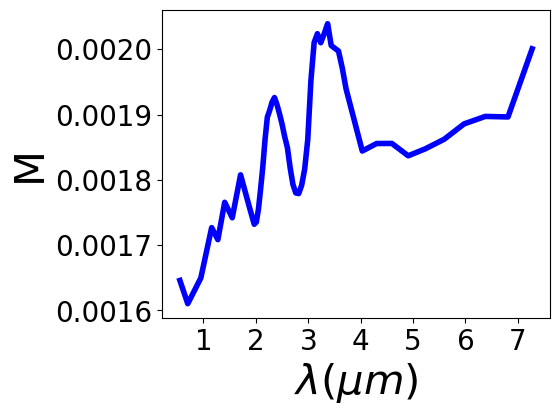

In [12]:
fig = plt.figure(figsize=(5,4))
plt.plot(wavelengths, spectra[0],color='b',lw=4)
plt.xlabel(r'$\lambda (\mu m)$',size=30)
plt.ylabel('M',size=30)
plt.xticks(size=20)
plt.yticks(size=20)
plt.savefig(plots_path+'transmission_spectra_example.png',bbox_inches='tight')

Distribution of maximum feature values per planet instance

In [13]:
spectra_max = np.max(spectra,axis=1)

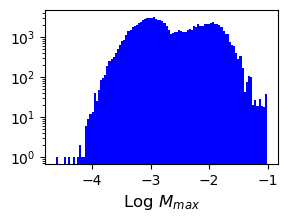

In [14]:
fig = plt.figure(figsize=(3,2))
plt.hist(np.log10(spectra_max), bins=100, color='b')
# plt.vlines(np.log10(1e-3),0.1,5000,color='r')
plt.xlabel('Log $M_{max}$', fontsize=12)
plt.yscale('log')

Remove small valued spectra, i.e. low signal data (<0.13$R_J$)

In [15]:
RJ = 71492000 # Jupiter radius in meters

In [16]:
ind_clean = aux_data_numpy[:,7]>=(0.13*RJ)
print('Remaining planets in the dataset:',ind_clean.sum())

Remaining planets in the dataset: 105447


Intermediate Cut on the Planet Radius

In [17]:
spectra_clean_int = spectra[ind_clean]
spectra_clean_10ppm_int = spectra_noise_10ppm[ind_clean]
spectra_clean_20ppm_int = spectra_noise_20ppm[ind_clean]
spectra_clean_30ppm_int = spectra_noise_30ppm[ind_clean]
spectra_clean_50ppm_int = spectra_noise_50ppm[ind_clean]

Final Cut on the Feature Height

In [18]:
feature_height_clean_int = np.max(spectra_clean_int,axis=1)-np.min(spectra_clean_int,axis=1)
ind_fh = feature_height_clean_int>2.1e-4
Nclean = ind_fh.sum()
feature_height_clean = feature_height_clean_int[ind_fh]
print('Remaining planets in the dataset:',ind_fh.sum())

Remaining planets in the dataset: 68934


Create final spectra arrays

In [19]:
spectra_clean       = spectra_clean_int[ind_fh]
spectra_clean_10ppm = spectra_clean_10ppm_int[ind_fh]
spectra_clean_20ppm = spectra_clean_20ppm_int[ind_fh]
spectra_clean_30ppm = spectra_clean_30ppm_int[ind_fh]
spectra_clean_50ppm = spectra_clean_50ppm_int[ind_fh]

In [20]:
spectra_clean.shape

(68934, 52)

We also must update the auxiliary data and forward model parameters.

In [21]:
fm_clean_int = fm_data_numpy[ind_clean]
aux_clean_int = aux_data_numpy[ind_clean]
fm_clean = fm_clean_int[ind_fh]
aux_clean = aux_clean_int[ind_fh]

print('Clean FM  shape:', fm_clean.shape)
print('Clean aux shape:', aux_clean.shape)

Clean FM  shape: (68934, 6)
Clean aux shape: (68934, 9)


/var/folders/sl/kqr05k6918j7cyzw0gf6zjzh0000gn/T/ipykernel_6037/1524776745.py:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(3,3,i+1)


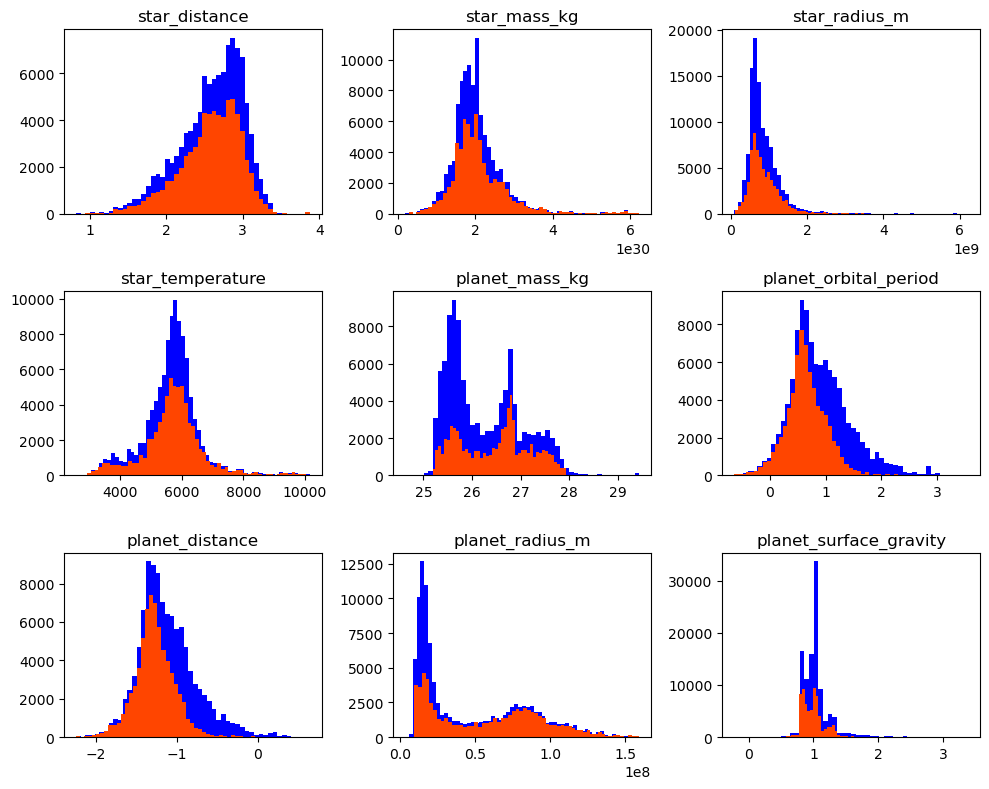

In [22]:
fig = plt.subplots(2,3,figsize = (10,8))
for i in range(aux_clean.shape[1]):
  plt.subplot(3,3,i+1)
  if i in [0,4,5,6,8]:
    plt.hist(np.log10(aux_data_numpy[:,i]),color='b',bins=50)
    plt.hist(np.log10(aux_clean[:,i]),color='orangered',bins=50)
  else:
    plt.hist(aux_data_numpy[:,i],color='b',bins=60)
    plt.hist(aux_clean[:,i],color='orangered',bins=60)
  plt.title(aux_keys[i])
plt.tight_layout()
plt.savefig(plots_path+'auxiliary_distributions.png',bbox_inches='tight')

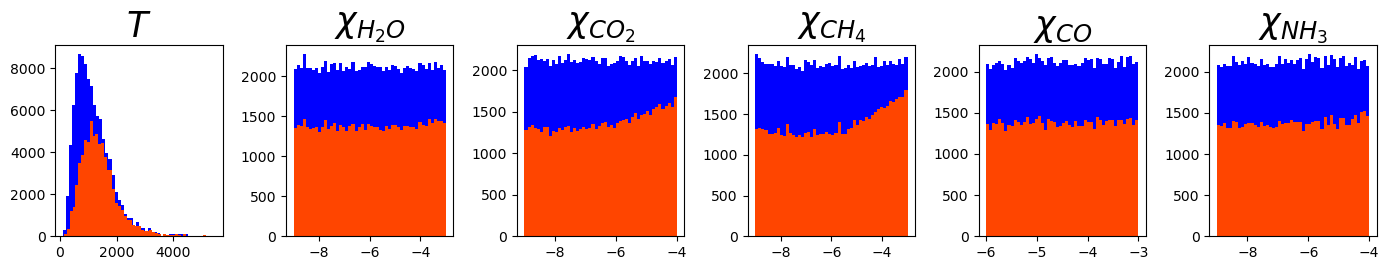

In [23]:
fig, axes = plt.subplots(1,6,figsize = (14,2.8))
colors = ['darkblue','blue','royalblue','cornflowerblue','lightskyblue','lightblue']
for i in range(len(keys)):
    plt.subplot(161+i)
    plt.hist(fm_data_numpy[:,i],bins=50,color='b',alpha = 1)
    plt.hist(fm_clean[:,i],bins=50,color='orangered',alpha = 1)
    plt.title(keys[i],fontsize=25)
    # plt.xticks([])
    # plt.yticks([])
fig.tight_layout()
plt.savefig(plots_path+'target_distributions.png',bbox_inches='tight')

In [24]:
feature_height = np.max(spectra,axis=1)-np.min(spectra,axis=1)

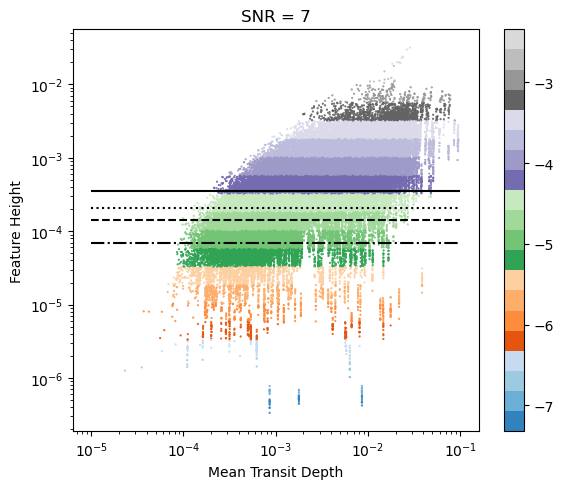

In [25]:
fig = plt.figure(figsize=(6,5))
plt.scatter(np.mean(spectra,axis=1),feature_height,c=np.log10((feature_height)/7),s=0.3,cmap='tab20c')
plt.hlines(7*1e-5,xmin=1e-5,xmax=1e-1,linestyle='-.',color='black')
plt.hlines(7*2e-5,xmin=1e-5,xmax=1e-1,linestyle='dashed',color='black')
plt.hlines(7*3e-5,xmin=1e-5,xmax=1e-1,linestyle='dotted',color='black')
plt.hlines(7*5e-5,xmin=1e-5,xmax=1e-1,linestyle='solid',color='black')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Mean Transit Depth')
plt.ylabel('Feature Height')
plt.title('SNR = 7')
plt.colorbar()
plt.tight_layout()
plt.savefig(plots_path+'feature_height_vs_mean_spectra_snr7.png',bbox_inches='tight')

## Standardization of the inputs with spectra as the only inputs(52 features, i.e. bins)

Concentration cut $>10^{-7}$ (no longer included)

In [26]:
# threshold = -7.
# inds = np.all(fm_data_numpy[:,1:]-threshold>0, axis=1)

In [27]:
# inds.shape

In [28]:
# np.sum(inds)

Reminder of the inputs and outputs we have available

In [29]:
# possible inputs
# spectra
spec_train = copy.deepcopy(spectra_clean)
spec_train_10ppm = copy.deepcopy(spectra_clean_10ppm)
spec_train_20ppm = copy.deepcopy(spectra_clean_20ppm)
spec_train_30ppm = copy.deepcopy(spectra_clean_30ppm)
spec_train_50ppm = copy.deepcopy(spectra_clean_50ppm)

# auxiliary data
aux_train = copy.deepcopy(aux_clean)

# targets; exponentiate log concentrations
fm_train = copy.deepcopy(fm_clean)
fm_train[:,1:] = np.power(10,fm_train[:,1:])

Standardize spectra, standardize auxiliary data and targets

In [30]:
# Normal
spec_means = np.mean(spec_train,axis=1)
spec_stds  = np.std(spec_train,axis=1)
spec_train = (spec_train - spec_means[:,None])/spec_stds[:,None]

# 10ppm
spec_means_10ppm = np.mean(spec_train_10ppm,axis=1)
spec_stds_10ppm  = np.std(spec_train_10ppm,axis=1)
spec_train_10ppm = (spec_train_10ppm - spec_means_10ppm[:,None])/spec_stds_10ppm[:,None]

# 20ppm
spec_means_20ppm = np.mean(spec_train_20ppm,axis=1)
spec_stds_20ppm  = np.std(spec_train_20ppm,axis=1)
spec_train_20ppm = (spec_train_20ppm - spec_means_20ppm[:,None])/spec_stds_20ppm[:,None]

# 30ppm
spec_means_30ppm = np.mean(spec_train_30ppm,axis=1)
spec_stds_30ppm  = np.std(spec_train_30ppm,axis=1)
spec_train_30ppm = (spec_train_30ppm - spec_means_30ppm[:,None])/spec_stds_30ppm[:,None]

# 50ppm
spec_means_50ppm = np.mean(spec_train_50ppm,axis=1)
spec_stds_50ppm  = np.std(spec_train_50ppm,axis=1)
spec_train_50ppm = (spec_train_50ppm - spec_means_50ppm[:,None])/spec_stds_50ppm[:,None]

aux_means = np.mean(aux_train,axis=0)
aux_stds  = np.std(aux_train,axis=0)
aux_train = (aux_train - aux_means)/aux_stds

targets_train_means = np.mean(fm_train,axis=0)
targets_train_stds  = np.std(fm_train,axis=0)
targets_train       = (fm_train - targets_train_means)/targets_train_stds

Refine the chosen data to the case of interest here

In [31]:
X = np.hstack([spec_train,aux_train])
Y = copy.deepcopy(targets_train)

In [32]:
# limit out of 91k
# N =  16000
# indsp = np.random.choice( np.arange(start=0,stop=np.sum(inds)), size=N, replace=False )
# x_train =  spec_train[:N]
# x_train = aux_and_spec_train[indsp]
# y_train = targets_train[indsp,:]

In [33]:
x_train, x_test, y_train, y_test = train_test_split(X,
                                                    Y,
                                                    test_size=0.20,
                                                    random_state=0)

In [34]:
chart_array = np.zeros((9,y_train.shape[1]*2))

# Method 1: Partial Least Squares (PLS) Regressor

In [35]:
# start = 20
# end = x_train.shape[1]+1
# pls_scores = np.zeros((end-start,))
# for i in tqdm(range(start,end,1)):
#     param_found_pls = {'n_components': i,
#                        'max_iter': 500, # does not affect outcome
#                        'scale': True,
#                        'tol': 1e-05, #tolerance
#                        'copy': True}

#     pls = PLSRegression(**param_found_pls)

#     # pls = PLSRegression(n_components=2,#61
#     #                     scale=True,
#     #                     max_iter=500,
#     #                     tol=1e-06,
#     #                     copy=True)

#     pls.fit(x_train,y_train)
#     # pred_pls = pls.predict(x_test)
#     score_pls = pls.score(x_test,y_test)
#     pls_scores[i-start] = score_pls

In [36]:
# plt.figure(figsize=(4,3))
# plt.plot([i for i in range(start,end,1)],pls_scores,c='b')
# plt.title('PLS Score as a Function of Components')
# plt.ylabel('Score')
# plt.xlabel('Components')
# plt.grid(visible=True)
# plt.savefig(plots_path+'pls_score_max500_scaleT_tol-5_'+designation+'.png')

In [37]:
np.random.seed(0)
# param_grid_pls = {'n_components':np.arange(53,62,2),
#                   'scale':[True,False],
#                   'max_iter':np.arange(500,2000,500),
#                   'tol':[1e-05,1e-06,1e-07],
#                   'copy':[True,False]}

# grid_pls = GridSearchCV(PLSRegression(), param_grid_pls, cv=2, verbose=1)
# grid_pls.fit(x_train, y_train)
# pls = grid_pls.best_estimator_
start = time()

param_found_pls = {'n_components': x_train.shape[1],
                   'max_iter': 500,
                   'scale': True,
                   'tol': 1e-05,
                   'copy': True}

pls = PLSRegression(**param_found_pls)


pls.fit(x_train,y_train)
pred_pls = pls.predict(x_test)
score_pls = pls.score(x_test,y_test)
print('Accuracy: ',score_pls)

end = time()
print('Duration',end-start)

Accuracy:  0.7453117116750568
Duration 5.737157106399536


In [38]:
sklearn_score(y_test,pred_pls)

0.7449527997472374

In [39]:
#grid_pls.best_estimator_

In [40]:
#grid_pls.best_params_

In [41]:
y_pred_back_pls = pred_pls*targets_train_stds + targets_train_means
y_test_back_pls = y_test*targets_train_stds + targets_train_means

score_pls_ariel = score(y_test_back_pls,y_pred_back_pls)
score_pls_mae   = mae(y_test_back_pls,y_pred_back_pls)
print('MAE: ',score_pls_mae)
print('Ariel Score: ',score_pls_ariel)

MAE:  1.947863689361635
Ariel Score:  -657697.5272466247


In [42]:
mae_col_pls = mae_per_col(y_test_back_pls,y_pred_back_pls)
inds0 = np.repeat([i for i in range(y_test.shape[0])],y_test.shape[1]) # Creates Index 0 vector
inds1=np.argsort(y_test_back_pls, axis=1)[:,::-1].flatten() # Creates Index 1 vector
mae_col_larg_to_small_pls = mae_per_col(y_test_back_pls[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]),
                                        y_pred_back_pls[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]))
chart_array[0,:]=np.hstack([mae_col_pls,mae_col_larg_to_small_pls])

In [43]:
mae_col_pls.shape

(1, 6)

In [44]:
inds0

array([    0,     0,     0, ..., 13786, 13786, 13786])

In [45]:
inds1

array([0, 4, 3, ..., 3, 1, 5])

/var/folders/sl/kqr05k6918j7cyzw0gf6zjzh0000gn/T/ipykernel_6037/502823050.py:11: RuntimeWarning: invalid value encountered in log10
  plt.scatter(np.log10(y_test_back_pls[:,i]),np.log10(y_pred_back_pls[:,i]),c=np.abs(np.log10(y_pred_back_pls[:,i])-np.log10(y_test_back_pls[:,i])),cmap='jet',s=1)


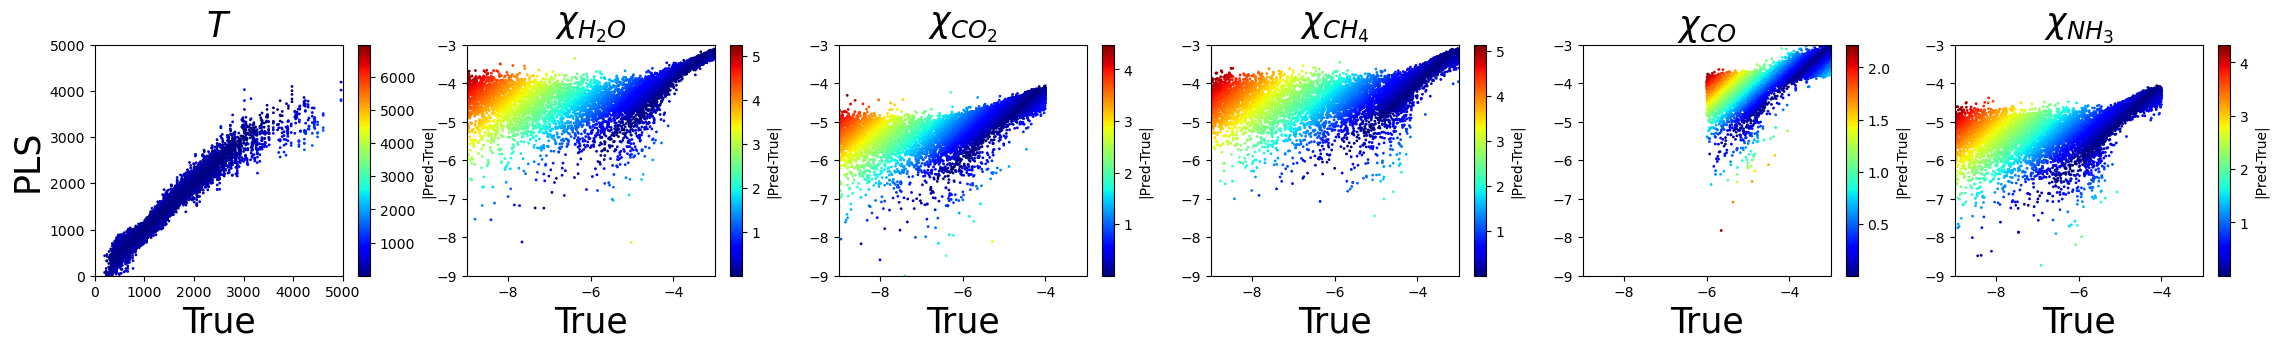

In [46]:
fig = plt.subplots(1,6,figsize=(28,3))

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.scatter(y_test_back_pls[:,i],y_pred_back_pls[:,i],c=np.abs(y_pred_back_pls[:,i]-y_test_back_pls[:,i]),cmap='jet',s=1)
        plt.ylabel('PLS',fontsize=25)
        plt.xlim([0,5000])
        plt.ylim([0,5000])
    else:
        plt.scatter(np.log10(y_test_back_pls[:,i]),np.log10(y_pred_back_pls[:,i]),c=np.abs(np.log10(y_pred_back_pls[:,i])-np.log10(y_test_back_pls[:,i])),cmap='jet',s=1)
        plt.xlim([-9,-3])
        plt.ylim([-9,-3])
    plt.colorbar(label='|Pred-True|')
    plt.xlabel('True',fontsize=25)
    plt.title(keys[i],fontsize=25)
plt.savefig(plots_path+'scatter_pls_'+designation+'.png',bbox_inches='tight')

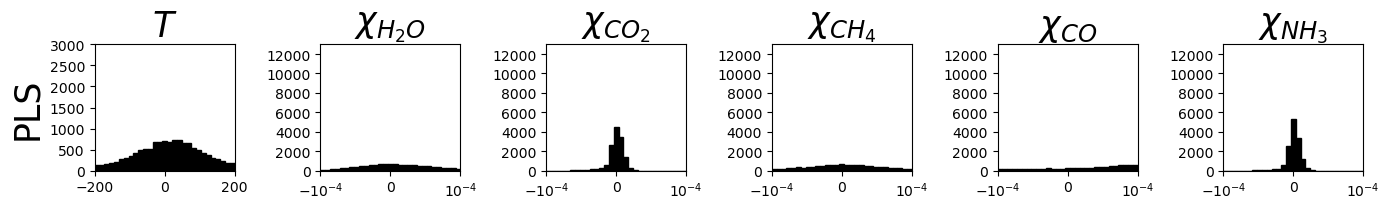

In [47]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_pls[:,i]-y_test_back_pls[:,i],bins=np.linspace(-tlim,tlim,30),color='black',edgecolor = "black")
        plt.ylabel('PLS',fontsize=25)
    else:
        plt.hist(y_pred_back_pls[:,i]-y_test_back_pls[:,i],bins=np.linspace(-clim,clim,30),color='black',edgecolor = "black")
    # plt.xticks(fontsize = 14)
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
    plt.title(keys[i], fontsize = 25)
fig.tight_layout()
plt.savefig(plots_path+'error_pls_'+designation+'.png',bbox_inches='tight')

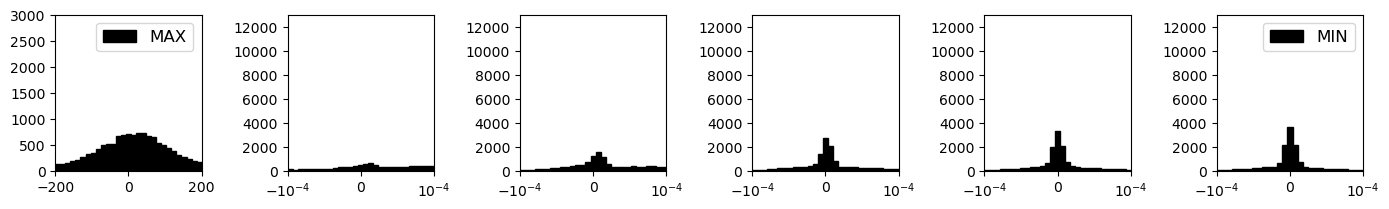

In [48]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_pls[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_pls[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-tlim,tlim,30),color='black',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    elif i==5:
        plt.hist(y_pred_back_pls[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_pls[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='black',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    else:
        plt.hist(y_pred_back_pls[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_pls[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='black',edgecolor = "black")
    # plt.xticks(fontsize = 14)
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
fig.tight_layout()
plt.savefig(plots_path+'error_maxmin_pls_'+designation+'.png',bbox_inches='tight')

# Method 2: Support Vector Machine (SVM) Regression

In [49]:
# discretization = 10
# discr_C = np.linspace(0.5,3000.,num=discretization)
# discr_gamma = np.linspace(0.005,0.2,num=discretization)
# svr_scores = np.zeros((discretization,discretization,3))
# for i, valC in tqdm(enumerate(discr_C)):
#     for j, valG in enumerate(discr_gamma):

#         # Initialize prediction arrays
#         pred_SVR   = np.empty((y_test.shape[0],6))

#         param_found_svr= {'C': valC,
#                             'cache_size': 200,
#                             'coef0': 0.0,  # only for polynomial and sigmoid kernels
#                             'degree': 3, # only used for polynomial kernels
#                             'epsilon': 0.1, #0.5
#                             'gamma': valG, #'scale'
#                             'kernel': 'rbf',
#                             'max_iter': -1,
#                             'shrinking': True,
#                             'tol': 0.001,
#                             'verbose': False}
#         svr_scores[i,j,0]  = valC
#         svr_scores[i,j,1] = valG
#         for k in range(len(target_train_keys)):
#             regr = SVR(**param_found_svr)
#             regr.fit(x_train,y_train[:,k])
#             pred_SVR = np.delete(pred_SVR,k,axis=1)
#             pred_SVR = np.insert(pred_SVR,k,regr.predict(x_test),axis=1)
#         svr_scores[i,j,2] = sklearn_score(y_test,pred_SVR)

In [50]:
# fig = plt.contourf(svr_scores[:,:,0],svr_scores[:,:,1],svr_scores[:,:,2],levels=40,cmap='viridis')
# plt.xlabel('Regularization parameter (C)')
# plt.ylabel('Kernel Coefficient ($\gamma$)')
# plt.colorbar(label='Score')
# plt.savefig('svr_C05to3000_0005to02_10.png')

In [51]:
np.random.seed(0)
scores_SVR = np.empty((6,1))
pred_SVR   = np.empty((y_test.shape[0],6))

# param_grid_svr = {'kernel':['linear', 'poly', 'rbf', 'sigmoid'],
#                    'degree':np.arange(3,5),
#                    'gamma':['scale', 'auto'],
#                    'coef0':np.arange(0,2),
#                    'tol':[1e-3],
#                    'C':np.arange(1,3),
#                    'epsilon':[5e-1,1e-1],
#                    'shrinking':[True,False],
#                    'cache_size':[200],
#                    'verbose':[False],
#                    'max_iter':[-1]}

# grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=2, verbose=1)
# i=1
# grid_svr.fit(x_train, y_train[:,i])
# regr = grid_svr.best_estimator_
param_found_svr= {'C':5,
                    'cache_size': 200,
                    'coef0': 0,  # only for polynomial and sigmoid kernels
                    'degree': 3, # only used for polynomial kernels
                    'epsilon': 0.1, #0.1
                    'gamma': 0.028,
                    'kernel': 'rbf',
                    'max_iter': -1,
                    'shrinking': True,
                    'tol': 0.001,
                    'verbose': False}

start = time()

for i in range(len(keys)):

    regr = SVR(**param_found_svr)

    regr.fit(x_train,y_train[:,i])
    pred_SVR = np.delete(pred_SVR,i,axis=1)
    pred_SVR = np.insert(pred_SVR,i,regr.predict(x_test),axis=1)
    scores_SVR[i] = regr.score(x_test,y_test[:,i])
    print('Accuracy for '+keys[i]+': ',np.round(scores_SVR[i],6))

end = time()
print('Duration',end-start)

Accuracy for $T$:  [0.992861]
Accuracy for $\chi_{H_2O}$:  [0.949932]
Accuracy for $\chi_{CO_2}$:  [0.938571]
Accuracy for $\chi_{CH_4}$:  [0.950655]
Accuracy for $\chi_{CO}$:  [0.790027]
Accuracy for $\chi_{NH_3}$:  [0.94844]
Duration 6731.403371810913


In [52]:
#grid_svr.best_params_

In [53]:
np.var(x_train)

0.9999562536459442

Typical gamma (kernel coefficient) value

In [54]:
1/(61*np.var(x_train))

0.016394159807670214

In [55]:
sklearn_score(y_test,pred_SVR)

0.928158899307578

Scoring

In [56]:
y_pred_back_SVR = pred_SVR*targets_train_stds + targets_train_means
y_test_back_SVR = y_test*targets_train_stds + targets_train_means

score_SVR_ariel = score(y_test_back_SVR,y_pred_back_SVR)
score_SVR_mae   = mae(y_test_back_SVR,y_pred_back_SVR)
print('MAE: ',score_SVR_mae)
print('Ariel Score: ',score_SVR_ariel)

MAE:  2.906695498874607
Ariel Score:  -101041.8847904741


In [57]:
mae_col_SVR = mae_per_col(y_test_back_SVR,y_pred_back_SVR)
inds0 = np.repeat([i for i in range(y_test.shape[0])],y_test.shape[1]) # Creates Index 0 vector
inds1=np.argsort(y_test_back_SVR, axis=1)[:,::-1].flatten() # Creates Index 1 vector
mae_col_larg_to_small_SVR = mae_per_col(y_test_back_SVR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]),y_pred_back_SVR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]))
chart_array[1,:]=np.hstack([mae_col_SVR,mae_col_larg_to_small_SVR])

/var/folders/sl/kqr05k6918j7cyzw0gf6zjzh0000gn/T/ipykernel_6037/3247161043.py:11: RuntimeWarning: invalid value encountered in log10
  plt.scatter(np.log10(y_test_back_SVR[:,i]),np.log10(y_pred_back_SVR[:,i]),c=np.abs(np.log10(y_pred_back_SVR[:,i])-np.log10(y_test_back_SVR[:,i])),cmap='jet',s=1)


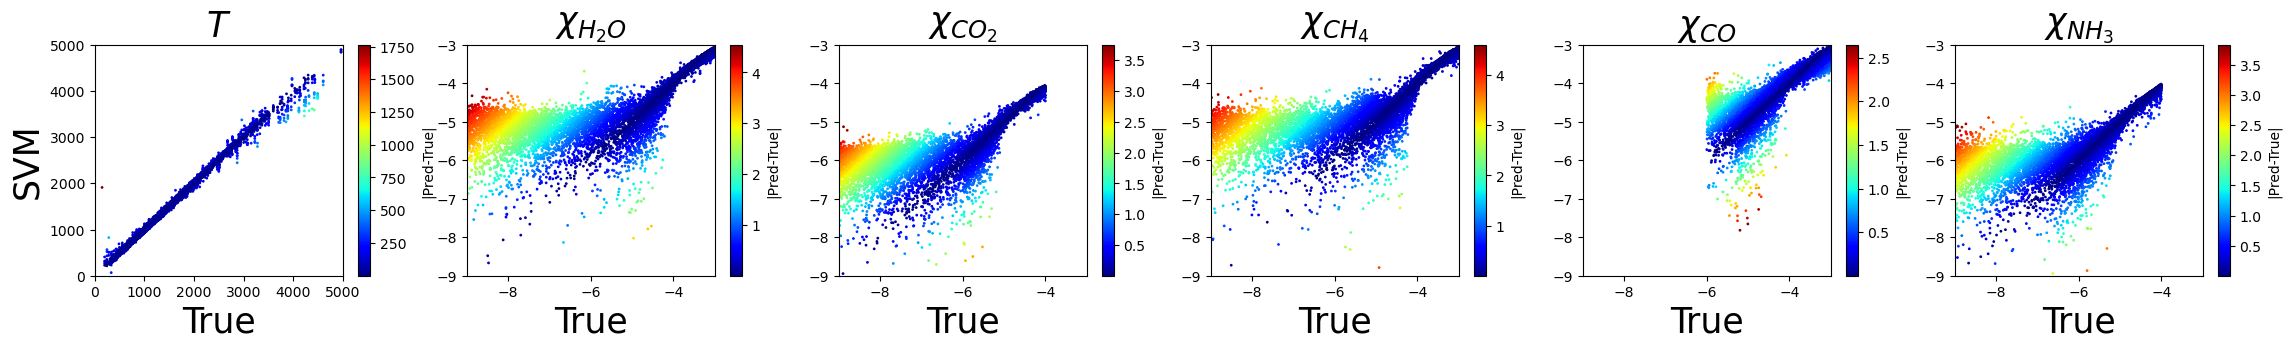

In [58]:
fig = plt.subplots(1,6,figsize=(28,3))

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.scatter(y_test_back_SVR[:,i],y_pred_back_SVR[:,i],c=np.abs(y_pred_back_SVR[:,i]-y_test_back_SVR[:,i]),cmap='jet',s=1)
        plt.ylabel('SVM',fontsize=25)
        plt.xlim([0,5000])
        plt.ylim([0,5000])
    else:
        plt.scatter(np.log10(y_test_back_SVR[:,i]),np.log10(y_pred_back_SVR[:,i]),c=np.abs(np.log10(y_pred_back_SVR[:,i])-np.log10(y_test_back_SVR[:,i])),cmap='jet',s=1)
        plt.xlim([-9,-3])
        plt.ylim([-9,-3])
    plt.colorbar(label='|Pred-True|')
    plt.xlabel('True',fontsize=25)
    plt.title(keys[i],fontsize=25)
plt.savefig(plots_path+'scatter_svm_'+designation+'.png',bbox_inches='tight')

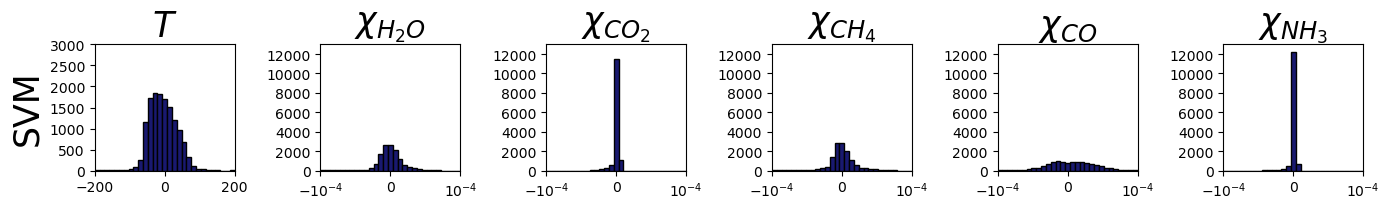

In [59]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000


for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_SVR[:,i]-y_test_back_SVR[:,i],bins=np.linspace(-tlim,tlim,30),color='midnightblue',edgecolor = "black")
        plt.ylabel('SVM',fontsize=25)
    else:
        plt.hist(y_pred_back_SVR[:,i]-y_test_back_SVR[:,i],bins=np.linspace(-clim,clim,30),color='midnightblue',edgecolor = "black")

    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
    plt.title(keys[i], fontsize = 25)
fig.tight_layout()
plt.savefig(plots_path+'error_svm_'+designation+'.png',bbox_inches='tight')

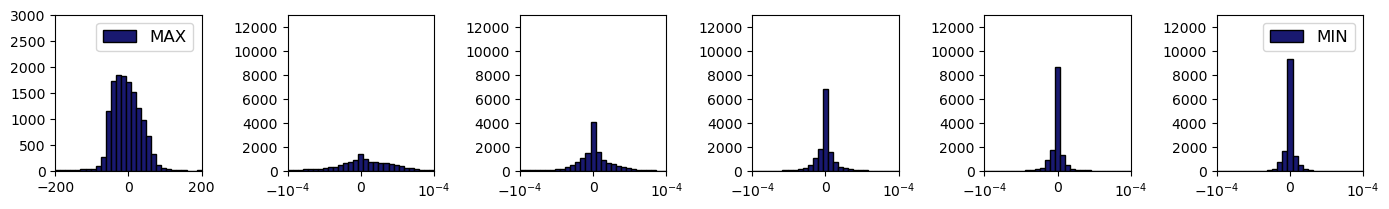

In [60]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_SVR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_SVR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-tlim,tlim,30),color='midnightblue',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    elif i==5:
        plt.hist(y_pred_back_SVR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_SVR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='midnightblue',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    else:
        plt.hist(y_pred_back_SVR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_SVR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='midnightblue',edgecolor = "black")
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
fig.tight_layout()
plt.savefig(plots_path+'error_maxmin_svm_'+designation+'.png',bbox_inches='tight')

# Method 3: k-Nearest Neighbors

In [61]:
# discretization = 20
# discr_N = np.linspace(2,42,num=discretization, dtype = np.int16)
# discr_leaf_size = np.linspace(20,40,num=discretization, dtype = np.int16)
# knn_scores = np.zeros((discretization,discretization,3))
# for i, valN in tqdm(enumerate(discr_N)):
#     for j, valL in enumerate(discr_leaf_size):
#         param_found_knn = {'n_neighbors':valN,
#                           'weights':'distance',
#                           'algorithm':'ball_tree',
#                           'leaf_size':valL,
#                           'p':1,
#                           'metric':'minkowski',
#                           'metric_params':None,
#                           'n_jobs':None}

#         knn_scores[i,j,0]  = valN
#         knn_scores[i,j,1] = valL

#         knn = KNeighborsRegressor(**param_found_knn)
#         knn.fit(x_train,y_train)
#         pred_KNN = knn.predict(x_test)
#         knn_scores[i,j,2] = sklearn_score(y_test,pred_KNN)

In [62]:
# fig = plt.contourf(knn_scores[:,:,0],knn_scores[:,:,1],knn_scores[:,:,2],levels=40,cmap='viridis')
# plt.xlabel('Number of Neighbors (N)')
# plt.ylabel('Leaf Size')
# plt.colorbar(label='Score')
# plt.savefig(plots_path+'knn_N02to42_20to40_10_'+designation+'.png')

In [63]:
# start = 2
# end = start+100
# knn_scores = np.zeros((end-start,))
# for i in tqdm(range(start,end,1)):
#     param_found_knn = {'n_neighbors':i,
#                         'weights':'distance',
#                         'algorithm':'ball_tree',
#                         'leaf_size':30,
#                         'p':1,
#                         'metric':'minkowski',
#                         'metric_params':None,
#                         'n_jobs':None}

#     knn = KNeighborsRegressor(**param_found_knn)

#     # pls = PLSRegression(n_components=2,#61
#     #                     scale=True,
#     #                     max_iter=500,
#     #                     tol=1e-06,
#     #                     copy=True)

#     knn.fit(x_train,y_train)
#     # pred_pls = pls.predict(x_test)
#     score_knn = knn.score(x_test,y_test)
#     knn_scores[i-start] = score_knn

In [64]:
# plt.figure(figsize=(4,3))
# plt.plot([i for i in range(start,end,1)],knn_scores,c='b')
# plt.title('KNN Score as a Function of Nearest Neighbors')
# plt.ylabel('Score')
# plt.xlabel('Neighbors')
# plt.grid(visible=True)
# plt.savefig(plots_path+'knn_score_neigh2to80_ls30_p1_'+designation+'.png')

In [65]:
np.random.seed(0)
# param_grid_knn = {'n_neighbors':np.arange(4,20,2),
#                   'weights':['uniform', 'distance'],
#                   'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute'],
#                   'leaf_size':np.arange(28,34,2),
#                   'p':[1,2],
#                   'metric':['minkowski'],
#                   'metric_params':[None],
#                   'n_jobs':[None]}

# grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=2, verbose=1)
# grid_knn.fit(x_train, y_train)
# neigh = grid_knn.best_estimator_

param_found_neigh = {'n_neighbors':6,
                  'weights':'distance',
                  'algorithm':'ball_tree',
                  'leaf_size':30,
                  'p':1,
                  'metric':'minkowski',
                  'metric_params':None,
                  'n_jobs':None}

start = time()

neigh = KNeighborsRegressor(**param_found_neigh)

neigh.fit(x_train,y_train)

pred_KNN = neigh.predict(x_test)
score_KNN = neigh.score(x_test,y_test)
print('Accuracy: ',score_KNN)

end = time()
print('Duration: ',end-start)

Accuracy:  0.7743545923183671
Duration:  183.28126525878906


In [66]:
# grid_knn.best_params_

In [67]:
sklearn_score(y_test,pred_KNN)

0.7732280362759222

Scoring

In [68]:
y_pred_back_KNN = pred_KNN*targets_train_stds + targets_train_means
y_test_back_KNN = y_test*targets_train_stds + targets_train_means

score_KNN_ariel = score(y_test_back_KNN,y_pred_back_KNN)
score_KNN_mae   = mae(y_test_back_KNN,y_pred_back_KNN)
print('MAE: ',score_KNN_mae)
print('Ariel Score: ',score_KNN_ariel)

MAE:  0.6751582298390822
Ariel Score:  -20882.08062505687


In [69]:
mae_col_KNN = mae_per_col(y_test_back_KNN,y_pred_back_KNN)
inds0 = np.repeat([i for i in range(y_test.shape[0])],y_test.shape[1]) # Creates Index 0 vector
inds1=np.argsort(y_test_back_KNN, axis=1)[:,::-1].flatten() # Creates Index 1 vector
mae_col_larg_to_small_KNN = mae_per_col(y_test_back_KNN[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]),y_pred_back_KNN[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]))
chart_array[2,:]=np.hstack([mae_col_KNN,mae_col_larg_to_small_KNN])

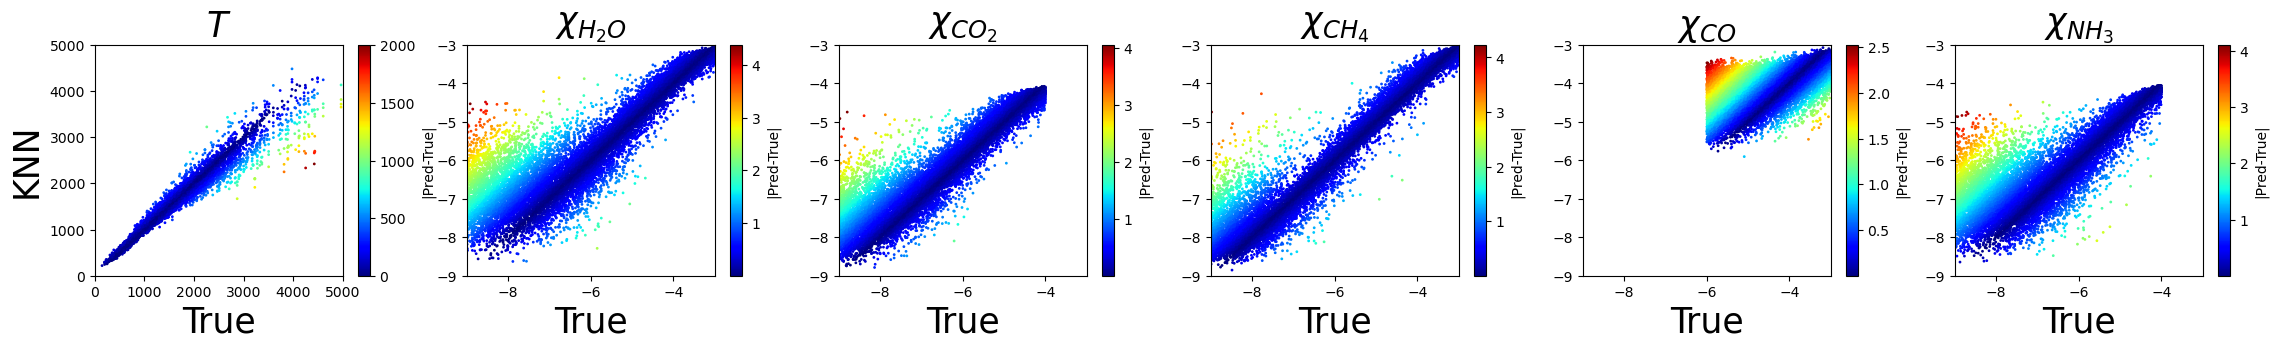

In [70]:
fig = plt.subplots(1,6,figsize=(28,3))

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.scatter(y_test_back_KNN[:,i],y_pred_back_KNN[:,i],c=np.abs(y_pred_back_KNN[:,i]-y_test_back_KNN[:,i]),cmap='jet',s=1)
        plt.ylabel('KNN',fontsize=25)
        plt.xlim([0,5000])
        plt.ylim([0,5000])
    else:
        plt.scatter(np.log10(y_test_back_KNN[:,i]),np.log10(y_pred_back_KNN[:,i]),c=np.abs(np.log10(y_pred_back_KNN[:,i])-np.log10(y_test_back_KNN[:,i])),cmap='jet',s=1)
        plt.xlim([-9,-3])
        plt.ylim([-9,-3])
    plt.colorbar(label='|Pred-True|')
    plt.xlabel('True',fontsize=25)
    plt.title(keys[i],fontsize=25)
plt.savefig(plots_path+'scatter_knn_'+designation+'.png',bbox_inches='tight')

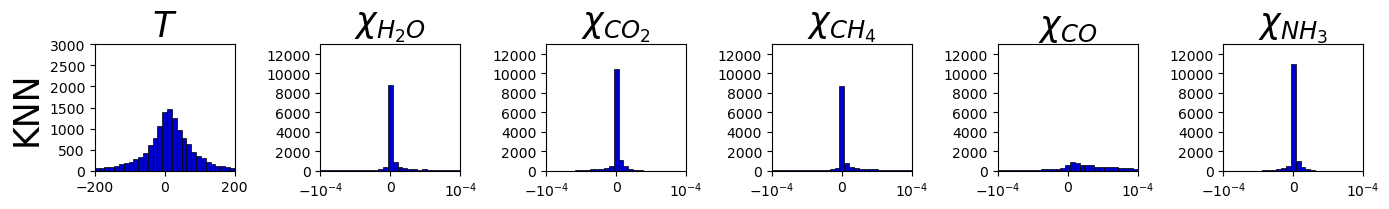

In [71]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000


for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_KNN[:,i]-y_test_back_KNN[:,i],bins=np.linspace(-tlim,tlim,30),color='mediumblue',lw=0.5,edgecolor = "black")
        plt.ylabel('KNN',fontsize=25)
    else:
        plt.hist(y_pred_back_KNN[:,i]-y_test_back_KNN[:,i],bins=np.linspace(-clim,clim,30),color='mediumblue',lw=0.5,edgecolor = "black")

    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
    plt.title(keys[i], fontsize = 25)
fig.tight_layout()
plt.savefig(plots_path+'error_knn_'+designation+'.png',bbox_inches='tight')

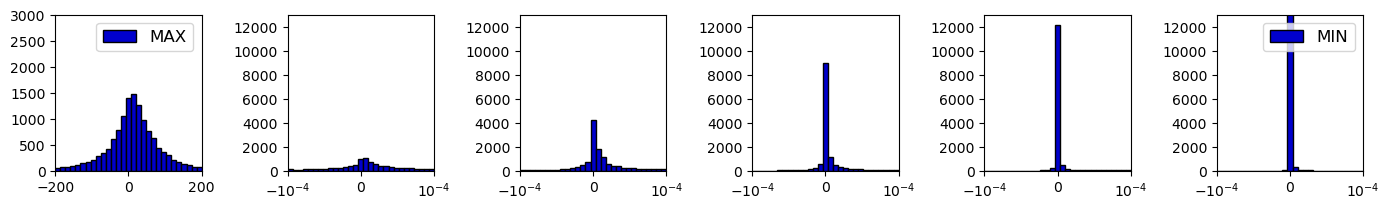

In [72]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000


for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_KNN[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_KNN[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-tlim,tlim,30),color='mediumblue',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    elif i==5:
        plt.hist(y_pred_back_KNN[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_KNN[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='mediumblue',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    else:
        plt.hist(y_pred_back_KNN[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_KNN[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='mediumblue',edgecolor = "black")
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
fig.tight_layout()
plt.savefig(plots_path+'error_maxmin_knn_'+designation+'.png',bbox_inches='tight')

# Method 4: Radius Neighbor Regressor

In [73]:
# start = 7
# end = start+100
# rnn_scores = np.zeros((end-start,))
# for i in tqdm(range(start,end,1)):
#     param_found_rnn = {'radius':i,  #15
#                       'weights':'distance',
#                       'algorithm':'ball_tree',
#                       'leaf_size':30,
#                       'p':2,
#                       'metric':'minkowski',
#                       'metric_params':None,
#                       'n_jobs':None}

#     rnn = RadiusNeighborsRegressor(**param_found_rnn)

#     rnn.fit(x_train,y_train)
#     pred_rnn = rnn.predict(x_test)
#     score_rnn = rnn.score(x_test,y_test)
#     rnn_scores[i-start] = score_rnn

In [74]:
# plt.figure(figsize=(4,3))
# plt.plot([i for i in range(start,end,1)],rnn_scores,c='b')
# plt.title('RNN Score as a Function of Nearest Neighbors')
# plt.ylabel('Score')
# plt.xlabel('Radius')
# plt.grid(visible=True)
# plt.savefig(plots_path+'rnn_score_rad7to40_ls30_p2_'+designation+'.png')

In [75]:
np.random.seed(0)
# %%capture
# param_grid_rnn = {'radius':np.arange(14,20,1),  #15
#                   'weights':['uniform', 'distance'],
#                   'algorithm':['auto', 'ball_tree', 'kd_tree', 'brute'],
#                   'leaf_size':np.arange(28,32),
#                   'p':np.arange(1,3),
#                   'metric':['minkowski'],
#                   'metric_params':[None],
#                   'n_jobs':[None,-1]}

# grid_rnn = GridSearchCV(RadiusNeighborsRegressor(), param_grid_rnn, cv=2, verbose=1)
# grid_rnn.fit(x_train, y_train)
# rneigh = grid_rnn.best_estimator_


param_found_rnr = {'radius':10,  #15
                  'weights':'distance',
                  'algorithm':'ball_tree',
                  'leaf_size':30,
                  'p':2,
                  'metric':'minkowski',
                  'metric_params':None,
                  'n_jobs':None}

start = time()

rnn = RadiusNeighborsRegressor(**param_found_rnr)

rnn.fit(x_train,y_train)
pred_rnn = rnn.predict(x_test)
score_rnn = rnn.score(x_test,y_test)
print('Accuracy: ',score_rnn)

end = time()
print('Duration: ',end-start)

Accuracy:  0.12310371779213403
Duration:  469.3791916370392


In [76]:
# grid_rnn.best_params_

In [77]:
y_pred_back_rnn = pred_rnn*targets_train_stds + targets_train_means
y_test_back_rnn = y_test*targets_train_stds + targets_train_means

score_rnn_ariel = score(y_test_back_rnn,y_pred_back_rnn)
score_rnn_mae   = mae(y_test_back_rnn,y_pred_back_rnn)
print('MAE: ',score_rnn_mae)
print('Ariel Score: ',score_rnn_ariel)

MAE:  1.2962480523233828
Ariel Score:  -634923.6754970667


In [78]:
mae_col_rnn = mae_per_col(y_test_back_rnn,y_pred_back_rnn)
inds0 = np.repeat([i for i in range(y_test.shape[0])],y_test.shape[1]) # Creates Index 0 vector
inds1=np.argsort(y_test_back_rnn, axis=1)[:,::-1].flatten() # Creates Index 1 vector
mae_col_larg_to_small_rnn = mae_per_col(y_test_back_rnn[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]),y_pred_back_rnn[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]))
chart_array[3,:]=np.hstack([mae_col_rnn,mae_col_larg_to_small_rnn])

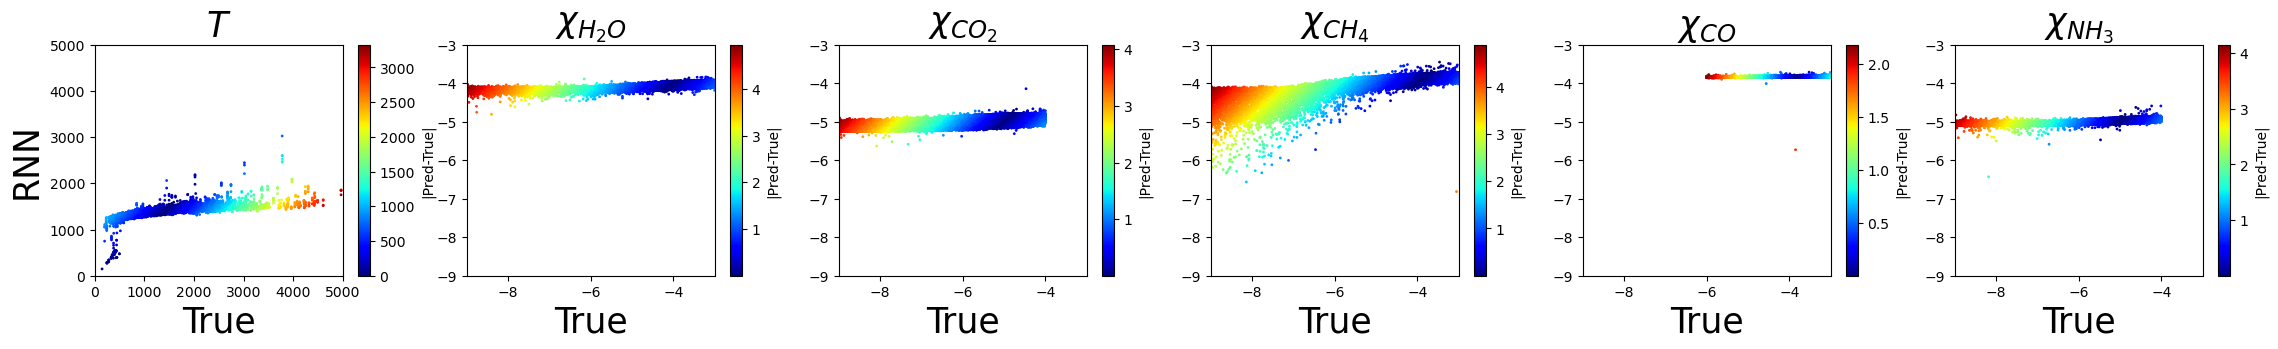

In [79]:
fig = plt.subplots(1,6,figsize=(28,3))

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.scatter(y_test_back_rnn[:,i],y_pred_back_rnn[:,i],c=np.abs(y_pred_back_rnn[:,i]-y_test_back_rnn[:,i]),cmap='jet',s=1)
        plt.ylabel('RNN',fontsize=25)
        plt.xlim([0,5000])
        plt.ylim([0,5000])
    else:
        plt.scatter(np.log10(y_test_back_rnn[:,i]),np.log10(y_pred_back_rnn[:,i]),c=np.abs(np.log10(y_pred_back_rnn[:,i])-np.log10(y_test_back_rnn[:,i])),cmap='jet',s=1)
        plt.xlim([-9,-3])
        plt.ylim([-9,-3])
    plt.colorbar(label='|Pred-True|')
    plt.xlabel('True',fontsize=25)
    plt.title(keys[i],fontsize=25)
plt.savefig(plots_path+'scatter_rnn_'+designation+'.png',bbox_inches='tight')

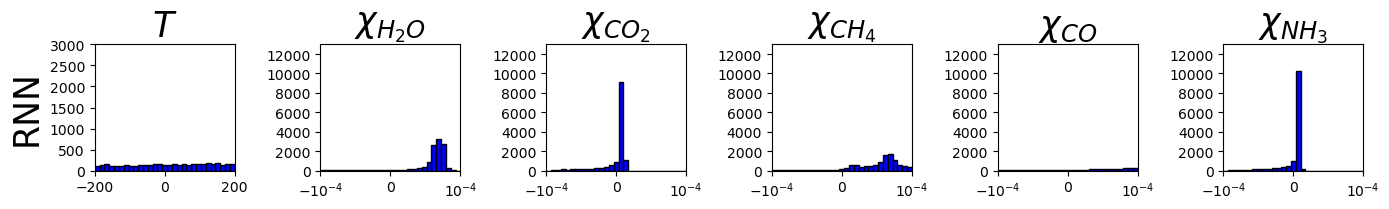

In [80]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000


for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_rnn[:,i]-y_test_back_rnn[:,i],bins=np.linspace(-tlim,tlim,30),color='blue',edgecolor = "black")
        plt.ylabel('RNN',fontsize=25)
    else:
        plt.hist(y_pred_back_rnn[:,i]-y_test_back_rnn[:,i],bins=np.linspace(-clim,clim,30),color='blue',edgecolor = "black")

    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
    plt.title(keys[i], fontsize = 25)
fig.tight_layout()
plt.savefig(plots_path+'error_rnn_'+designation+'.png',bbox_inches='tight')

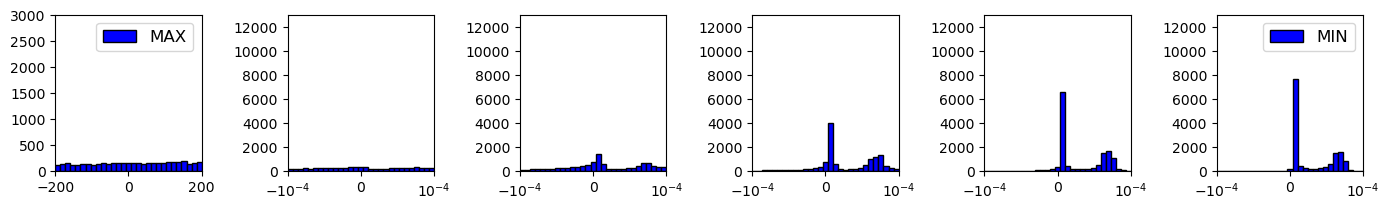

In [81]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_rnn[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_rnn[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-tlim,tlim,30),color='blue',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    elif i==5:
        plt.hist(y_pred_back_rnn[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_rnn[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='blue',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    else:
        plt.hist(y_pred_back_rnn[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_rnn[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='blue',edgecolor = "black")
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
fig.tight_layout()
plt.savefig(plots_path+'error_maxmin_rnn_'+designation+'.png',bbox_inches='tight')

# Method 5: Decision Tree Regression

In [82]:
# discretization = 30
# discr_minS = np.linspace(2,60,num=discretization, dtype = np.int16)
# discr_minwL = np.linspace(0.0,0.05,num=discretization)#, dtype = np.int16)
# dtr_scores = np.zeros((discretization,discretization,3))
# for i, val1 in tqdm(enumerate(discr_minS)):
#     for j, val2 in enumerate(discr_minwL):

#         param_found_dtr = {'criterion':'squared_error',
#                           'splitter':'random',
#                           'max_depth':None,
#                           'min_samples_split':val1,
#                           'min_samples_leaf':13,
#                           'min_weight_fraction_leaf':val2,
#                           'max_features':'sqrt',
#                           'random_state':None,
#                           'max_leaf_nodes':None,
#                           'min_impurity_decrease':0.0,
#                           'ccp_alpha':0.0}

#         dtr_scores[i,j,0] = val1
#         dtr_scores[i,j,1] = val2

#         dtr = DecisionTreeRegressor(**param_found_dtr)

#         dtr.fit(x_train,y_train)
#         pred_DTR  = dtr.predict(x_test)
#         score_DTR = dtr.score(x_test,y_test)
#         dtr_scores[i,j,2] = score_DTR

In [83]:
# max_indx = np.where(dtr_scores[:,:,:]==np.max(dtr_scores[:,:,2]))

In [84]:
# max_indx

In [85]:
# dtr_scores[max_indx[0],max_indx[1]]

In [86]:
# fig = plt.contourf(dtr_scores[:,:,0],dtr_scores[:,:,1],dtr_scores[:,:,2],levels=40,cmap='viridis')
# plt.xlabel('Maximum Samples to Split a Node')
# plt.ylabel('Minimum Weighted Fraction of the Sum Total of Weights')
# plt.colorbar(label='Score')
# plt.savefig(plots_path+'dtr_minS02to60_minwfL00to005_30_'+designation+'.png')

In [87]:
# discretization = 20
# discr_minF = np.linspace(2,42,num=discretization, dtype = np.int16)
# discr_minID = np.linspace(0.0,0.01,num=discretization)#, dtype = np.int16)
# dtr_scores = np.zeros((discretization,discretization,3))
# for i, val1 in tqdm(enumerate(discr_minF)):
#     for j, val2 in enumerate(discr_minID):

#         param_found_dtr = {'criterion':'squared_error',
#                           'splitter':'random',
#                           'max_depth':None,
#                           'min_samples_split':48,
#                           'min_samples_leaf':13,
#                           'min_weight_fraction_leaf':1.72413793e-03,
#                           'max_features':val1,
#                           'random_state':None,
#                           'max_leaf_nodes':None,
#                           'min_impurity_decrease':val2,
#                           'ccp_alpha':0.0}

#         dtr_scores[i,j,0] = val1
#         dtr_scores[i,j,1] = val2

#         dtr = DecisionTreeRegressor(**param_found_dtr)

#         dtr.fit(x_train,y_train)
#         pred_DTR  = dtr.predict(x_test)
#         score_DTR = dtr.score(x_test,y_test)
#         dtr_scores[i,j,2] = score_DTR

In [88]:
# max_indx = np.where(dtr_scores[:,:,:]==np.max(dtr_scores[:,:,2]))

In [89]:
# max_indx

In [90]:
# dtr_scores[max_indx[0],max_indx[1]]

In [91]:
# fig = plt.contourf(dtr_scores[:,:,0],dtr_scores[:,:,1],dtr_scores[:,:,2],levels=40,cmap='viridis')
# plt.xlabel('Maximum Features')
# plt.ylabel('Minimum Impurity Decrease')
# plt.colorbar(label='Score')
# plt.savefig(plots_path+'dtr_maxF02to42_minID00to001_20_'+designation+'.png')

In [92]:
np.random.seed(0)
# %%capture
# param_grid_dtr = {'criterion':['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
#                   'splitter':['best','random'],
#                   'max_depth':[None],
#                   'min_samples_split':np.arange(1,4),
#                   'min_samples_leaf':np.arange(1,3),
#                   'min_weight_fraction_leaf':[0.0],
#                   'max_features':['auto', 'sqrt', 'log2',1.0],
#                   'random_state':[None],
#                   'max_leaf_nodes':[None],
#                   'min_impurity_decrease':[0.0],
#                   'ccp_alpha':[0.0,1.0]}

# grid_dtr = GridSearchCV(DecisionTreeRegressor(), param_grid_dtr, cv=2, verbose=1)
# grid_dtr.fit(x_train, y_train)
# dtr = grid_dtr.best_estimator_


param_found_dtr = {'criterion':'squared_error',
                  'splitter':'random',
                  'max_depth':None,
                  'min_samples_split':48,
                  'min_samples_leaf':13,
                  'min_weight_fraction_leaf':1.72413793e-03,
                  'max_features':29,
                  'random_state':None,
                  'max_leaf_nodes':None,
                  'min_impurity_decrease':1.05263158e-03,
                  'ccp_alpha':0.0}

start = time()

dtr = DecisionTreeRegressor(**param_found_dtr)

dtr.fit(x_train,y_train)
pred_DTR  = dtr.predict(x_test)
score_DTR = dtr.score(x_test,y_test)
print('Accuracy: ', score_DTR)

end = time()
print('Duration: ', end-start)

Accuracy:  0.5204636160875751
Duration:  0.2665679454803467


In [93]:
# grid_dtr.best_params_

Scoring

In [94]:
y_pred_back_DTR = pred_DTR*targets_train_stds + targets_train_means
y_test_back_DTR = y_test*targets_train_stds + targets_train_means

score_DTR_ariel = score(y_test_back_DTR,y_pred_back_DTR)
score_DTR_mae   = mae(y_test_back_DTR,y_pred_back_DTR)
print('MAE: ',score_DTR_mae)
print('Ariel Score: ',score_DTR_ariel)

MAE:  1.080036173800247
Ariel Score:  -187918.99816928754


In [95]:
mae_col_DTR = mae_per_col(y_test_back_DTR,y_pred_back_DTR)
inds0 = np.repeat([i for i in range(y_test.shape[0])],y_test.shape[1]) # Creates Index 0 vector
inds1=np.argsort(y_test_back_DTR, axis=1)[:,::-1].flatten() # Creates Index 1 vector
mae_col_larg_to_small_DTR = mae_per_col(y_test_back_DTR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]),y_pred_back_DTR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]))
chart_array[4,:]=np.hstack([mae_col_DTR,mae_col_larg_to_small_DTR])

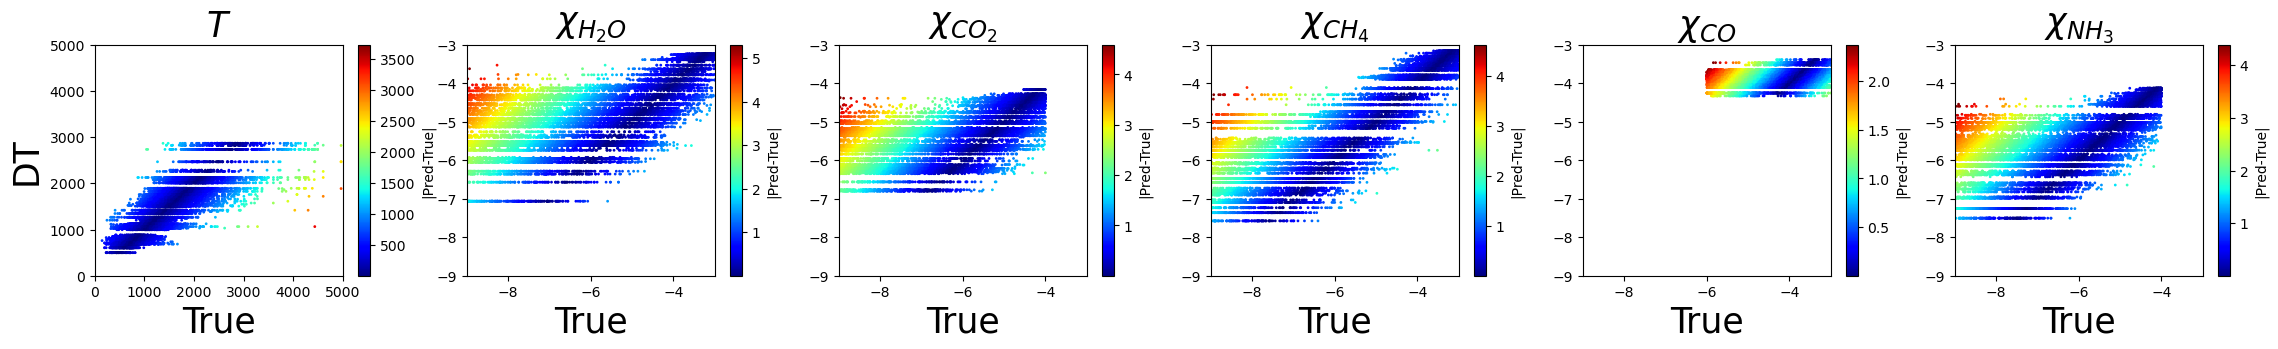

In [96]:
fig = plt.subplots(1,6,figsize=(28,3))

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.scatter(y_test_back_DTR[:,i],y_pred_back_DTR[:,i],c=np.abs(y_pred_back_DTR[:,i]-y_test_back_DTR[:,i]),cmap='jet',s=1)
        plt.ylabel('DT',fontsize=25)
        plt.xlim([0,5000])
        plt.ylim([0,5000])
    else:
        plt.scatter(np.log10(y_test_back_DTR[:,i]),np.log10(y_pred_back_DTR[:,i]),c=np.abs(np.log10(y_pred_back_DTR[:,i])-np.log10(y_test_back_DTR[:,i])),cmap='jet',s=1)
        plt.xlim([-9,-3])
        plt.ylim([-9,-3])
    plt.colorbar(label='|Pred-True|')
    plt.xlabel('True',fontsize=25)
    plt.title(keys[i],fontsize=25)
plt.savefig(plots_path+'scatter_dtr_'+designation+'.png',bbox_inches='tight')

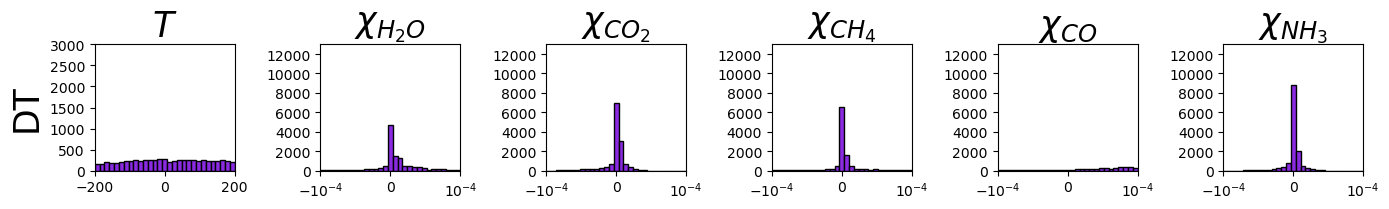

In [97]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000


for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_DTR[:,i]-y_test_back_DTR[:,i],bins=np.linspace(-tlim,tlim,30),color='blueviolet',edgecolor = "black")
        plt.ylabel('DT',fontsize=25)
    else:
        plt.hist(y_pred_back_DTR[:,i]-y_test_back_DTR[:,i],bins=np.linspace(-clim,clim,30),color='blueviolet',edgecolor = "black")

    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
    plt.title(keys[i], fontsize = 25)
fig.tight_layout()
plt.savefig(plots_path+'error_dtr_'+designation+'.png',bbox_inches='tight')

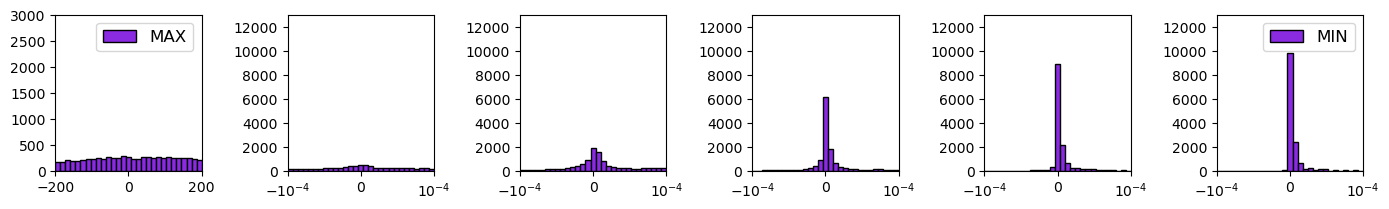

In [98]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_DTR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_DTR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-tlim,tlim,30),color='blueviolet',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    elif i==5:
        plt.hist(y_pred_back_DTR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_DTR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='blueviolet',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    else:
        plt.hist(y_pred_back_DTR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_DTR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='blueviolet',edgecolor = "black")
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
fig.tight_layout()
plt.savefig(plots_path+'error_maxmin_dtr_'+designation+'.png',bbox_inches='tight')

# Method 6: Random Forest Regression

In [99]:
# discretization = 20
# discr_nE = np.linspace(40,400,num=discretization, dtype = np.int16)
# discr_minS = np.linspace(2,100,num=discretization, dtype = np.int16)
# rfr_scores = np.zeros((discretization,discretization,3))
# for i, val1 in tqdm(enumerate(discr_nE)):
#     for j, val2 in enumerate(discr_minS):

#         param_found_rfr = {'n_estimators':val1,
#                           'criterion':'squared_error',
#                           'max_depth':None,
#                           'min_samples_split':val2,
#                           'min_samples_leaf':13,
#                           'min_weight_fraction_leaf':1.72413793e-03,
#                           'max_features':29,
#                           'max_leaf_nodes':None,
#                           'min_impurity_decrease':1.05263158e-03,
#                           'bootstrap':True,
#                           'oob_score':False,
#                           'n_jobs':None,
#                           'random_state':None,
#                           'verbose':0,
#                           'warm_start':False,
#                           'ccp_alpha':0.0,
#                           'max_samples':None}

#         rfr_scores[i,j,0] = val1
#         rfr_scores[i,j,1] = val2

#         rfr = RandomForestRegressor(**param_found_rfr)

#         rfr.fit(x_train,y_train)
#         pred_RFR  = rfr.predict(x_test)
#         score_RFR = rfr.score(x_test,y_test)

#         rfr_scores[i,j,2] = score_RFR

In [100]:
# max_indx = np.where(rfr_scores[:,:,:]==np.max(rfr_scores[:,:,2]))

In [101]:
# max_indx

In [102]:
# rfr_scores[max_indx[0],max_indx[1]]

In [103]:
# fig = plt.contourf(rfr_scores[:,:,0],rfr_scores[:,:,1],rfr_scores[:,:,2],levels=40,cmap='viridis')
# plt.xlabel('Number of Trees')
# plt.ylabel('Minimum Samples to Split a Node')
# plt.colorbar(label='Score')
# plt.savefig(plots_path+'rfr_nT40to400_minS0001to1_20_'+designation+'.png')

In [104]:
np.random.seed(0)
# param_grid_rfr = {'n_estimators':np.arange(90,120,10),
#                   'criterion':['squared_error','absolute_error','friedman_mse','poisson'],
#                   'max_depth':[None],
#                   'min_samples_split':np.arange(1,3),
#                   'min_samples_leaf':np.arange(1,3,1),
#                   'min_weight_fraction_leaf':[0.0],
#                   'max_features':['sqrt', 'log2', None, 1.0],
#                   'max_leaf_nodes':[None],
#                   'min_impurity_decrease':[0.0],
#                   'bootstrap':[True,False],
#                   'oob_score':[True,False],
#                   'n_jobs':[None],
#                   'random_state':[None],
#                   'verbose':[0],
#                   'warm_start':[False],
#                   'ccp_alpha':[0.0],
#                   'max_samples':[None]}

# grid_rfr = GridSearchCV(RandomForestRegressor(), param_grid_rfr, cv=2, verbose=1)
# grid_rfr.fit(x_train, y_train)
# rfr = grid_rfr.best_estimator_

param_found_rfr = {'n_estimators':115,
                  'criterion':'squared_error',
                  'max_depth':None,
                  'min_samples_split':48,
                  'min_samples_leaf':13,
                  'min_weight_fraction_leaf':1.72413793e-03,
                  'max_features':27,
                  'max_leaf_nodes':None,
                  'min_impurity_decrease':1.05263158e-03,
                  'bootstrap':True,
                  'oob_score':False,
                  'n_jobs':None,
                  'random_state':None,
                  'verbose':0,
                  'warm_start':False,
                  'ccp_alpha':0.0,
                  'max_samples':None}

rfr = RandomForestRegressor(**param_found_rfr)

start = time()

rfr.fit(x_train,y_train)
pred_RFR  = rfr.predict(x_test)
score_RFR = rfr.score(x_test,y_test)
print('Accuracy: ', score_RFR)

end = time()
print('Duration: ', end-start)

Accuracy:  0.7045458375759952
Duration:  160.39987707138062


In [105]:
# grid_rfr.best_params_

Scoring

In [106]:
y_pred_back_RFR = pred_RFR*targets_train_stds + targets_train_means
y_test_back_RFR = y_test*targets_train_stds + targets_train_means

score_RFR_ariel = score(y_test_back_RFR,y_pred_back_RFR)
score_RFR_mae   = mae(y_test_back_RFR,y_pred_back_RFR)
print('MAE: ',score_RFR_mae)
print('Ariel Score: ',score_RFR_ariel)

MAE:  1.0616368902811768
Ariel Score:  -149971.12699200877


In [107]:
mae_col_RFR = mae_per_col(y_test_back_RFR,y_pred_back_RFR)
inds0 = np.repeat([i for i in range(y_test.shape[0])],y_test.shape[1]) # Creates Index 0 vector
inds1=np.argsort(y_test_back_RFR, axis=1)[:,::-1].flatten() # Creates Index 1 vector
mae_col_larg_to_small_RFR = mae_per_col(y_test_back_RFR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]),y_pred_back_RFR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]))
chart_array[5,:]=np.hstack([mae_col_RFR,mae_col_larg_to_small_RFR])

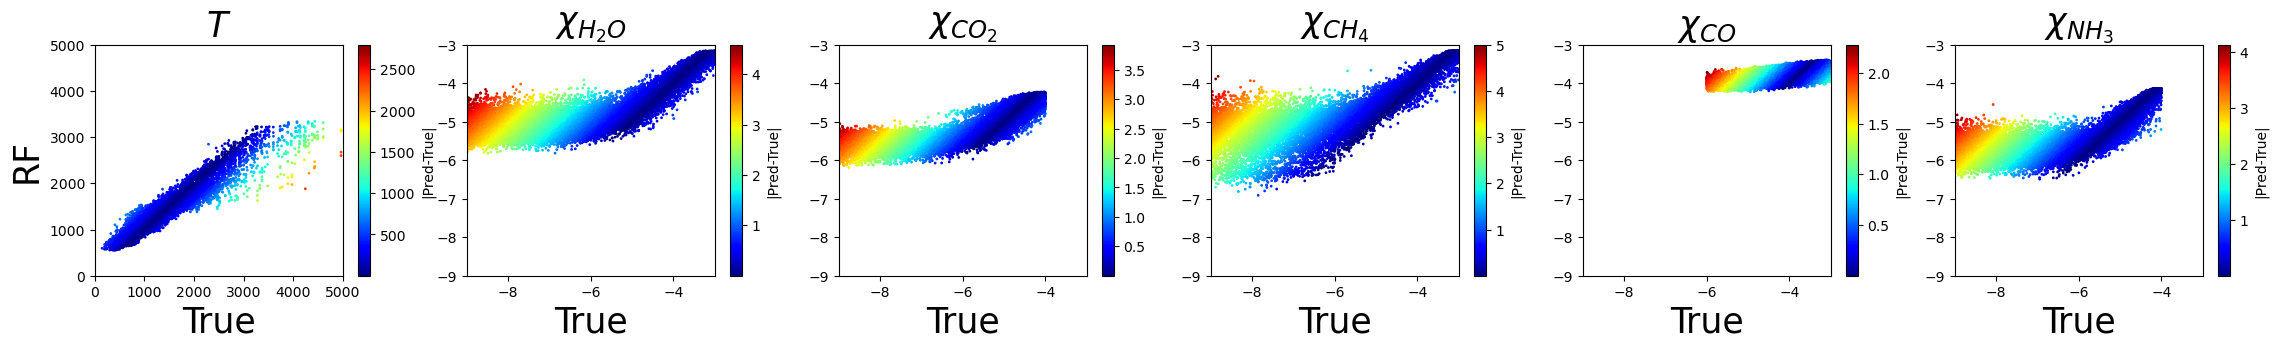

In [108]:
fig = plt.subplots(1,6,figsize=(28,3))

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.scatter(y_test_back_RFR[:,i],y_pred_back_RFR[:,i],c=np.abs(y_pred_back_RFR[:,i]-y_test_back_RFR[:,i]),cmap='jet',s=1)
        plt.ylabel('RF',fontsize=25)
        plt.xlim([0,5000])
        plt.ylim([0,5000])
    else:
        plt.scatter(np.log10(y_test_back_RFR[:,i]),np.log10(y_pred_back_RFR[:,i]),c=np.abs(np.log10(y_pred_back_RFR[:,i])-np.log10(y_test_back_RFR[:,i])),cmap='jet',s=1)
        plt.xlim([-9,-3])
        plt.ylim([-9,-3])
    plt.colorbar(label='|Pred-True|')
    plt.xlabel('True',fontsize=25)
    plt.title(keys[i],fontsize=25)
plt.savefig(plots_path+'scatter_rfr_'+designation+'.png',bbox_inches='tight')

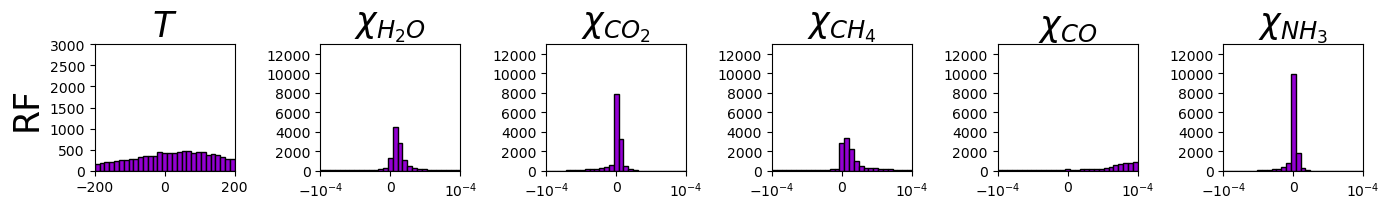

In [109]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000


for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_RFR[:,i]-y_test_back_RFR[:,i],bins=np.linspace(-tlim,tlim,30),color='darkviolet',edgecolor = "black")
        plt.ylabel('RF',fontsize=25)
    else:
        plt.hist(y_pred_back_RFR[:,i]-y_test_back_RFR[:,i],bins=np.linspace(-clim,clim,30),color='darkviolet',edgecolor = "black")

    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
    plt.title(keys[i], fontsize = 25)
fig.tight_layout()
plt.savefig(plots_path+'error_rfr_'+designation+'.png',bbox_inches='tight')

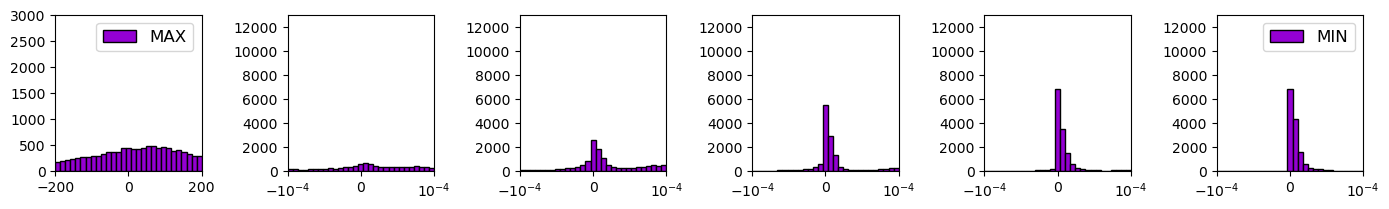

In [110]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_RFR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_RFR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-tlim,tlim,30),color='darkviolet',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    elif i==5:
        plt.hist(y_pred_back_RFR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_RFR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='darkviolet',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    else:
        plt.hist(y_pred_back_RFR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_RFR[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='darkviolet',edgecolor = "black")
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
fig.tight_layout()
plt.savefig(plots_path+'error_maxmin_rfr_'+designation+'.png',bbox_inches='tight')

# Method 7: Ensemble Methods (Voting Regression)

In [111]:
np.random.seed(0)
SVR_reg = SVR(**param_found_svr)
KNN_reg = KNeighborsRegressor(**param_found_neigh)
DTR_reg = DecisionTreeRegressor(**param_found_dtr)
RFR_reg = RandomForestRegressor(**param_found_rfr)

scores_vreg = np.empty((6,1))
pred_vreg   = np.empty((y_test.shape[0],6))

start = time()
for i in range(len(keys)):
    estimators = [('svr', SVR_reg), ('knn', KNN_reg), ('dtr', DTR_reg), ('rfr', RFR_reg)]
    voting_reg = VotingRegressor(estimators=estimators)
    voting_reg.fit(x_train, y_train[:,i])
    pred_vreg = np.delete(pred_vreg,i,axis=1)
    pred_vreg = np.insert(pred_vreg,i,voting_reg.predict(x_test),axis=1)
    scores_vreg[i] = voting_reg.score(x_test,y_test[:,i])
    print('Accuracy for '+keys[i]+': ',np.round(scores_vreg[i],6))

end = time()
print('Duration: ', end-start)

Accuracy for $T$:  [0.964762]
Accuracy for $\chi_{H_2O}$:  [0.89387]
Accuracy for $\chi_{CO_2}$:  [0.84751]
Accuracy for $\chi_{CH_4}$:  [0.918178]
Accuracy for $\chi_{CO}$:  [0.573219]
Accuracy for $\chi_{NH_3}$:  [0.913889]
Duration:  7920.159128189087


Scoring

In [112]:
y_pred_back_vreg = pred_vreg*targets_train_stds + targets_train_means
y_test_back_vreg = y_test*targets_train_stds + targets_train_means

score_vreg_ariel = score(y_test_back_vreg,y_pred_back_vreg)
score_vreg_mae   = mae(y_test_back_vreg,y_pred_back_vreg)
print('---Overall---')
print('MAE: ',score_vreg_mae)
print('Ariel Score: ',score_vreg_ariel)
print()

score_vreg_mae_each = np.empty((6,1))
score_vreg_ariel_each = np.empty((6,1))
for i in range(6):
    print('---'+keys[i]+'---')
    score_vreg_mae_each[i]    = mae(y_test_back_vreg[:,i],y_pred_back_vreg[:,i])
    score_vreg_ariel_each[i]  = score(y_test_back_vreg[:,i],y_pred_back_vreg[:,i])
    print('MAE: ',score_vreg_mae_each[i][0])
    print('Ariel Score: ',score_vreg_ariel_each[i][0])
    print()

---Overall---
MAE:  1.0820896105445132
Ariel Score:  -69362.18500540887

---$T$---
MAE:  0.05912576714114366
Ariel Score:  995.6742797752165

---$\chi_{H_2O}$---
MAE:  1.3218453860417418
Ariel Score:  -65217.450902258905

---$\chi_{CO_2}$---
MAE:  1.2113270031310877
Ariel Score:  -5311.415039279954

---$\chi_{CH_4}$---
MAE:  1.8265702222887865
Ariel Score:  -19595.595554125175

---$\chi_{CO}$---
MAE:  1.0066487568584817
Ariel Score:  424.30469235295647

---$\chi_{NH_3}$---
MAE:  1.0670205278058393
Ariel Score:  -9086.739558254854



In [113]:
mae_col_vreg = mae_per_col(y_test_back_vreg,y_pred_back_vreg)
inds0 = np.repeat([i for i in range(y_test.shape[0])],y_test.shape[1]) # Creates Index 0 vector
inds1=np.argsort(y_test_back_vreg, axis=1)[:,::-1].flatten() # Creates Index 1 vector
mae_col_larg_to_small_vreg = mae_per_col(y_test_back_vreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]),y_pred_back_vreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]))
chart_array[6,:]=np.hstack([mae_col_vreg,mae_col_larg_to_small_vreg])

/var/folders/sl/kqr05k6918j7cyzw0gf6zjzh0000gn/T/ipykernel_6037/2249674748.py:11: RuntimeWarning: invalid value encountered in log10
  plt.scatter(np.log10(y_test_back_vreg[:,i]),np.log10(y_pred_back_vreg[:,i]),c=np.abs(np.log10(y_pred_back_vreg[:,i])-np.log10(y_test_back_vreg[:,i])),cmap='jet',s=1)


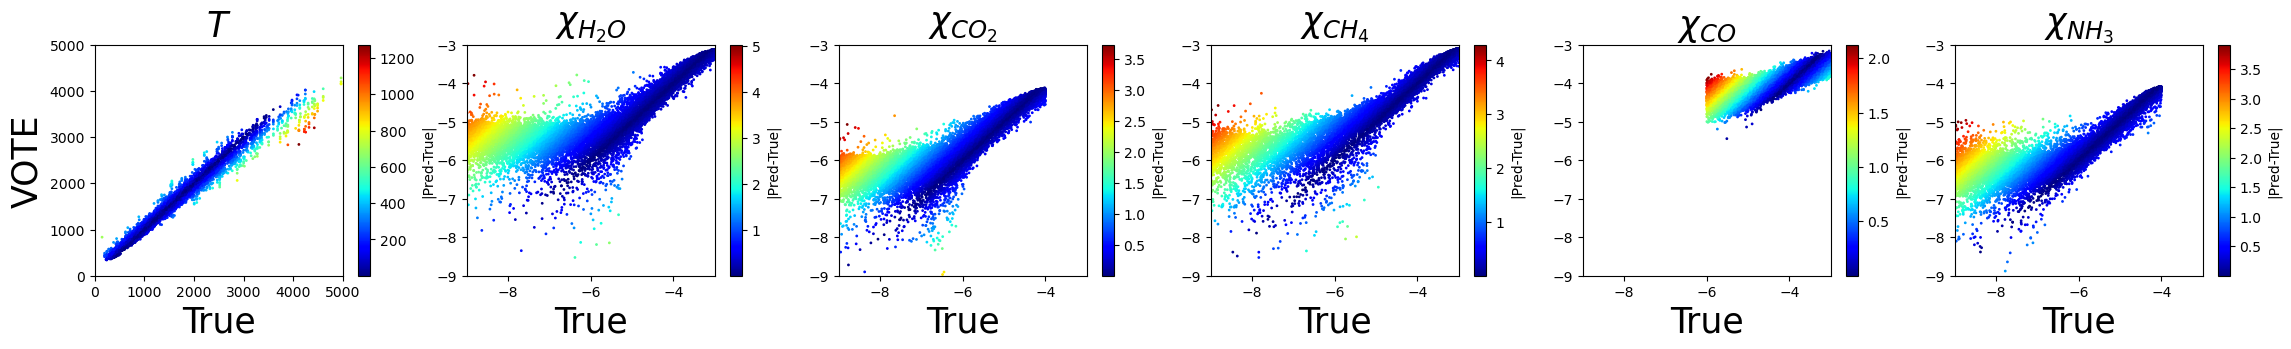

In [114]:
fig = plt.subplots(1,6,figsize=(28,3))

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.scatter(y_test_back_vreg[:,i],y_pred_back_vreg[:,i],c=np.abs(y_pred_back_vreg[:,i]-y_test_back_vreg[:,i]),cmap='jet',s=1)
        plt.ylabel('VOTE',fontsize=25)
        plt.xlim([0,5000])
        plt.ylim([0,5000])
    else:
        plt.scatter(np.log10(y_test_back_vreg[:,i]),np.log10(y_pred_back_vreg[:,i]),c=np.abs(np.log10(y_pred_back_vreg[:,i])-np.log10(y_test_back_vreg[:,i])),cmap='jet',s=1)
        plt.xlim([-9,-3])
        plt.ylim([-9,-3])
    plt.colorbar(label='|Pred-True|')
    plt.xlabel('True',fontsize=25)
    plt.title(keys[i],fontsize=25)
plt.savefig(plots_path+'scatter_votereg_'+designation+'.png',bbox_inches='tight')

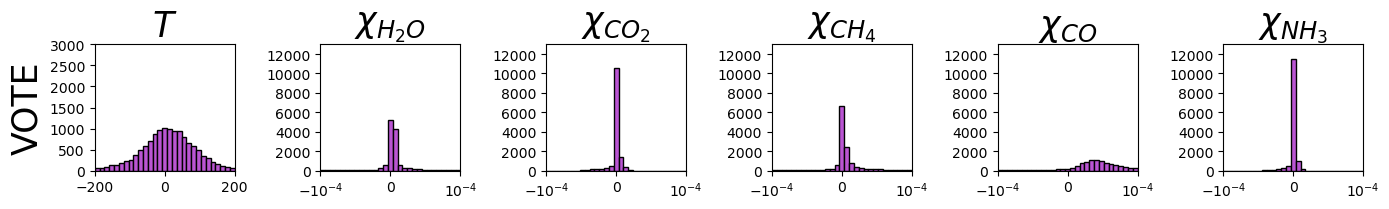

In [115]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000


for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_vreg[:,i]-y_test_back_vreg[:,i],bins=np.linspace(-tlim,tlim,30),color='mediumorchid',edgecolor = "black")
        plt.ylabel('VOTE',fontsize=25)
    else:
        plt.hist(y_pred_back_vreg[:,i]-y_test_back_vreg[:,i],bins=np.linspace(-clim,clim,30),color='mediumorchid',edgecolor = "black")

    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
    plt.title(keys[i], fontsize = 25)
fig.tight_layout()
plt.savefig(plots_path+'error_votereg_'+designation+'.png',bbox_inches='tight')

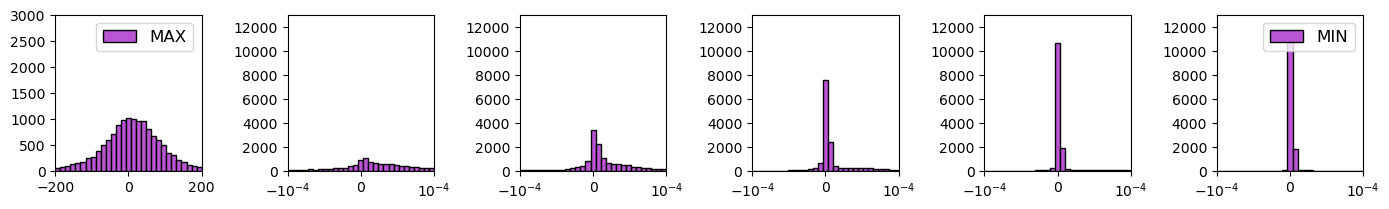

In [116]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_vreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_vreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-tlim,tlim,30),color='mediumorchid',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    elif i==5:
        plt.hist(y_pred_back_vreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_vreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='mediumorchid',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    else:
        plt.hist(y_pred_back_vreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_vreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='mediumorchid',edgecolor = "black")
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
fig.tight_layout()
plt.savefig(plots_path+'error_maxmin_votereg_'+designation+'.png',bbox_inches='tight')

# Method 8: Ensemble Methods (Stacking and Bagging)

In [117]:
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import BaggingRegressor

In [118]:
np.random.seed(0)
scores_sreg = np.empty((6,1))
pred_sreg   = np.empty((y_test.shape[0],6))

start = time()

for i in range(len(keys)):
    estimators = [('svr', SVR_reg), ('knn', KNN_reg), ('dtr', DTR_reg)]
    stacking_reg = StackingRegressor(estimators=estimators,final_estimator=RandomForestRegressor(n_estimators=10))
    stacking_reg.fit(x_train, y_train[:,i])
    pred_sreg = np.delete(pred_sreg,i,axis=1)
    pred_sreg = np.insert(pred_sreg,i,stacking_reg.predict(x_test),axis=1)
    scores_sreg[i] = stacking_reg.score(x_test,y_test[:,i])
    print('Accuracy for '+keys[i]+': ',np.round(scores_sreg[i],6))

end = time()
print('Duration: ', end-start)

Accuracy for $T$:  [0.993842]
Accuracy for $\chi_{H_2O}$:  [0.962656]
Accuracy for $\chi_{CO_2}$:  [0.957478]
Accuracy for $\chi_{CH_4}$:  [0.962466]
Accuracy for $\chi_{CO}$:  [0.840011]
Accuracy for $\chi_{NH_3}$:  [0.949428]
Duration:  23947.572047948837


In [119]:
y_pred_back_sreg = pred_sreg*targets_train_stds + targets_train_means
y_test_back_sreg = y_test*targets_train_stds + targets_train_means

score_sreg_ariel = score(y_test_back_sreg,y_pred_back_sreg)
score_sreg_mae   = mae(y_test_back_sreg,y_pred_back_sreg)
print('---Overall---')
print('MAE: ',score_sreg_mae)
print('Ariel Score: ',score_sreg_ariel)
print()

score_sreg_mae_each = np.empty((6,1))
score_sreg_ariel_each = np.empty((6,1))
for i in range(6):
    print('---'+keys[i]+'---')
    score_sreg_mae_each[i]    = mae(y_test_back_sreg[:,i],y_pred_back_sreg[:,i])
    score_sreg_ariel_each[i]  = score(y_test_back_sreg[:,i],y_pred_back_sreg[:,i])
    print('MAE: ',score_sreg_mae_each[i][0])
    print('Ariel Score: ',score_sreg_ariel_each[i][0])
    print()

---Overall---
MAE:  0.5447821787531937
Ariel Score:  -15819.153262377444

---$T$---
MAE:  0.022205855784481237
Ariel Score:  996.3336418086101

---$\chi_{H_2O}$---
MAE:  0.8215924645995973
Ariel Score:  -11253.99567721569

---$\chi_{CO_2}$---
MAE:  0.6136355559175654
Ariel Score:  -1525.0532686259294

---$\chi_{CH_4}$---
MAE:  0.5347533735127947
Ariel Score:  -8134.289555626283

---$\chi_{CO}$---
MAE:  0.49109551298919696
Ariel Score:  877.8192916194345

---$\chi_{NH_3}$---
MAE:  0.7854103097155264
Ariel Score:  -5549.612594880422



In [120]:
mae_col_sreg = mae_per_col(y_test_back_sreg,y_pred_back_sreg)
inds0 = np.repeat([i for i in range(y_test.shape[0])],y_test.shape[1]) # Creates Index 0 vector
inds1=np.argsort(y_test_back_sreg, axis=1)[:,::-1].flatten() # Creates Index 1 vector
mae_col_larg_to_small_sreg = mae_per_col(y_test_back_sreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]),y_pred_back_sreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]))
chart_array[7,:]=np.hstack([mae_col_sreg,mae_col_larg_to_small_sreg])

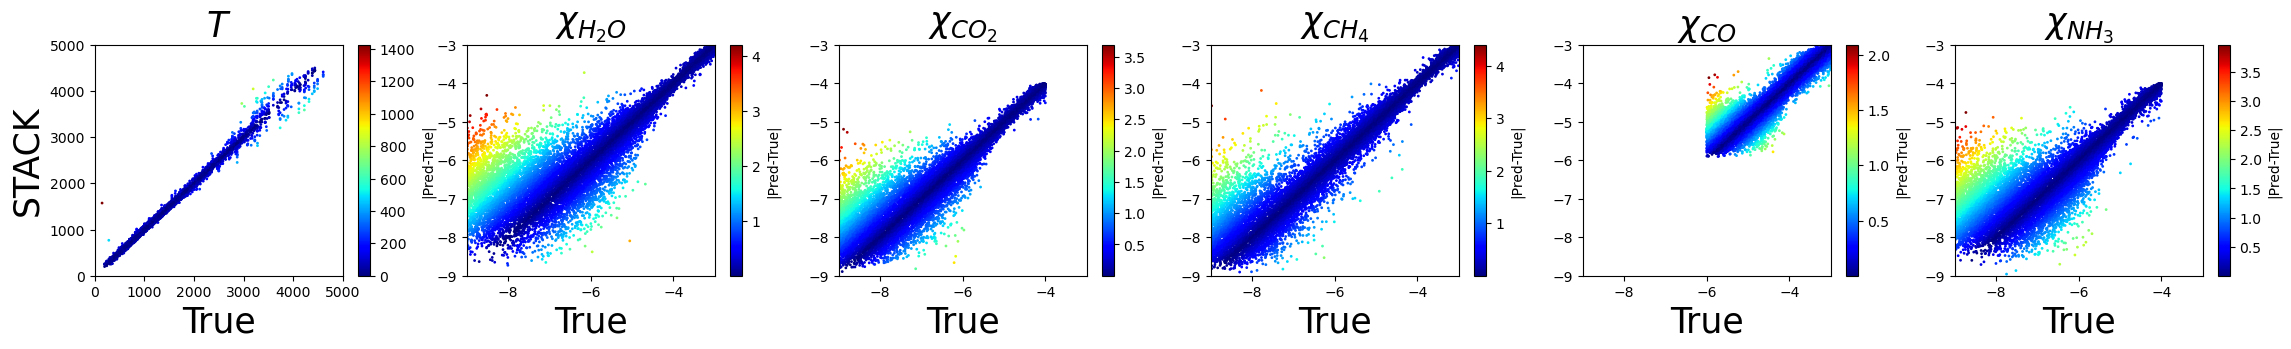

In [121]:
fig = plt.subplots(1,6,figsize=(28,3))

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.scatter(y_test_back_sreg[:,i],y_pred_back_sreg[:,i],c=np.abs(y_pred_back_sreg[:,i]-y_test_back_sreg[:,i]),cmap='jet',s=1)
        plt.ylabel('STACK',fontsize=25)
        plt.xlim([0,5000])
        plt.ylim([0,5000])
    else:
        plt.scatter(np.log10(y_test_back_sreg[:,i]),np.log10(y_pred_back_sreg[:,i]),c=np.abs(np.log10(y_pred_back_sreg[:,i])-np.log10(y_test_back_sreg[:,i])),cmap='jet',s=1)
        plt.xlim([-9,-3])
        plt.ylim([-9,-3])
    plt.colorbar(label='|Pred-True|')
    plt.xlabel('True',fontsize=25)
    plt.title(keys[i],fontsize=25)
plt.savefig(plots_path+'scatter_stackreg_'+designation+'.png',bbox_inches='tight')

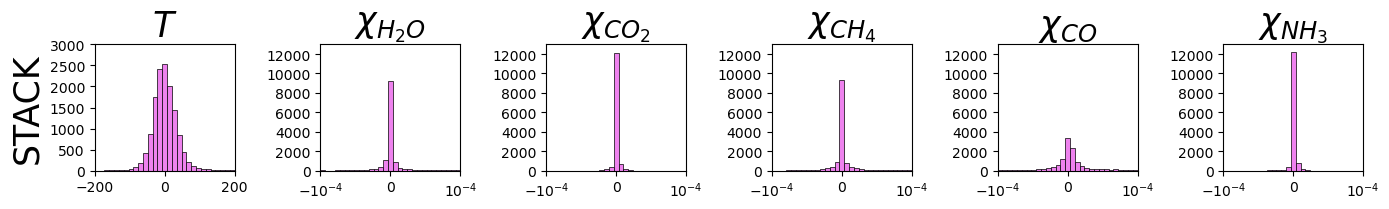

In [122]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000


for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_sreg[:,i]-y_test_back_sreg[:,i],bins=np.linspace(-tlim,tlim,30),color='violet',lw=0.5,edgecolor = "black")
        plt.ylabel('STACK',fontsize=25)
    else:
        plt.hist(y_pred_back_sreg[:,i]-y_test_back_sreg[:,i],bins=np.linspace(-clim,clim,30),color='violet',lw=0.5,edgecolor = "black")

    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
    plt.title(keys[i], fontsize = 25)
fig.tight_layout()
plt.savefig(plots_path+'error_stackreg_'+designation+'.png',bbox_inches='tight')

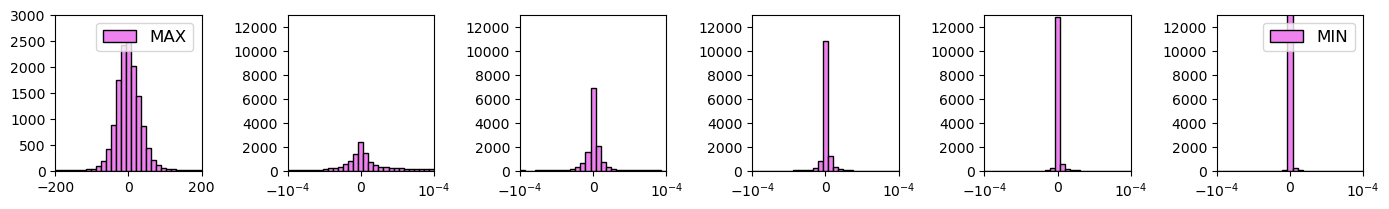

In [123]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_sreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_sreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-tlim,tlim,30),color='violet',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    elif i==5:
        plt.hist(y_pred_back_sreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_sreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='violet',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    else:
        plt.hist(y_pred_back_sreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_sreg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='violet',edgecolor = "black")
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
fig.tight_layout()
plt.savefig(plots_path+'error_maxmin_stackreg_'+designation+'.png',bbox_inches='tight')

# Method 9: Ensemble Methods (Boosting - Ada, Gradient, XGB)

In [124]:
# run this if you need to install xgboost
#pip install xgboost

In [125]:
from sklearn.ensemble import GradientBoostingRegressor

In [126]:
try:
    import xgboost
except ImportError as ex:
    print("Error: the xgboost library is not installed.")
    xgboost = None

In [127]:
# if xgboost is not None:  # not shown in the book
#     xgb_reg = xgboost.XGBRegressor(random_state=42)
#     xgb_reg.fit(x_train, y_train)
#     y_pred_xg = xgb_reg.predict(x_test)
#     val_error = mean_squared_error(y_test, y_pred_xg) # Not shown
#     print("Validation MSE:", val_error)           # Not shown

In [128]:
if xgboost is not None:  # not shown in the book
    start = time()
    xgb_reg = xgboost.XGBRegressor(#n_estimators=500,
                    # max_depth=3,
                     # learning_rate=1e-1,
                     random_state=42,early_stopping_rounds=15)
                    #  max_depth= 0,
                    #  max_leaves=0,
                    # max_bin=256,
                    # grow_policy='depthwise',
                    # verbosity = 0,
                    #  objective,
                    # booster='gbtree',
                    # tree_method='auto',
                    # n_jobs=1,
                    # gamma=0,
                    # min_child_weight=1,
                    #  max_delta_step,
                    # subsample=1)
                    #  sampling_method,
                    #  colsample_bytree=1,
                    #  colsample_bytree,
                    #  colsample_bylevel,
                    #  colsample_bynode,
                    #  reg_alpha,
                    #  reg_lambda,
                    #  scale_pos_weight,
                    #  base_score,
                    #  random_state,
                    #  missing,
                    #  num_parallel_tree,
                    #  monotone_constraints,
                    #  interaction_constraints,
                    #  importance_type,
                    #  gpu_id,
                    #  validate_parameters,
                    #  predictor,
                    #  enable_categorical,
                    #  feature_types,
                    #  max_cat_to_onehot,
                    #  max_cat_threshold,
                    #  eval_metric,
                    #  early_stopping_rounds,
                    #  callbacks)

    xgb_reg.fit(X=x_train,
                y=y_train,
                eval_set=[(x_test, y_test)],
                verbose=False  )

    y_pred_xgb = xgb_reg.predict(x_test)
    val_error = mean_squared_error(y_test, y_pred_xgb)

    y_pred_back_xg = y_pred_xgb*targets_train_stds + targets_train_means
    y_test_back_xg = y_test*targets_train_stds + targets_train_means

    score_xgb_ariel = score(y_test_back_xg,y_pred_back_xg)
    score_xgb_mae   = mae(y_test_back_xg,y_pred_back_xg)
    print('---Overall---')
    print('MAE: ',score_xgb_mae)
    print('Ariel Score: ',score_xgb_ariel)
end = time()
print('Duration: ', end - start)

---Overall---
MAE:  2.537592370303147
Ariel Score:  -41661.09970062957
Duration:  223.77748012542725


In [129]:
mae_col_xg = mae_per_col(y_test_back_xg,y_pred_back_xg)
inds0 = np.repeat([i for i in range(y_test.shape[0])],y_test.shape[1]) # Creates Index 0 vector
inds1=np.argsort(y_test_back_xg, axis=1)[:,::-1].flatten() # Creates Index 1 vector
mae_col_larg_to_small_xg = mae_per_col(y_test_back_xg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]),y_pred_back_xg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1]))
chart_array[8,:]=np.hstack([mae_col_xg,mae_col_larg_to_small_xg])

/var/folders/sl/kqr05k6918j7cyzw0gf6zjzh0000gn/T/ipykernel_6037/4208664930.py:11: RuntimeWarning: invalid value encountered in log10
  plt.scatter(np.log10(y_test_back_xg[:,i]),np.log10(y_pred_back_xg[:,i]),c=np.abs(np.log10(y_pred_back_xg[:,i])-np.log10(y_test_back_xg[:,i])),cmap='jet',s=1)


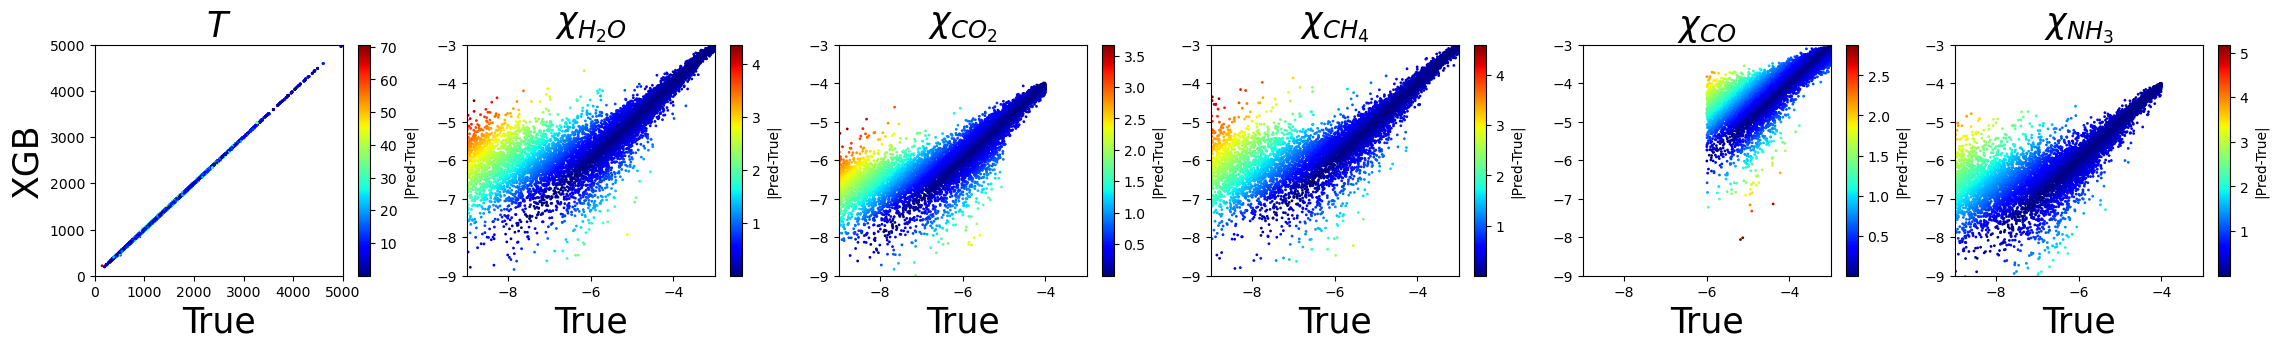

In [130]:
fig = plt.subplots(1,6,figsize=(28,3))

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.scatter(y_test_back_xg[:,i],y_pred_back_xg[:,i],c=np.abs(y_pred_back_xg[:,i]-y_test_back_xg[:,i]),cmap='jet',s=1)
        plt.ylabel('XGB',fontsize=25)
        plt.xlim([0,5000])
        plt.ylim([0,5000])
    else:
        plt.scatter(np.log10(y_test_back_xg[:,i]),np.log10(y_pred_back_xg[:,i]),c=np.abs(np.log10(y_pred_back_xg[:,i])-np.log10(y_test_back_xg[:,i])),cmap='jet',s=1)
        plt.xlim([-9,-3])
        plt.ylim([-9,-3])
    plt.colorbar(label='|Pred-True|')
    plt.xlabel('True',fontsize=25)
    plt.title(keys[i],fontsize=25)
plt.savefig(plots_path+'scatter_xgb_'+designation+'.png',bbox_inches='tight')

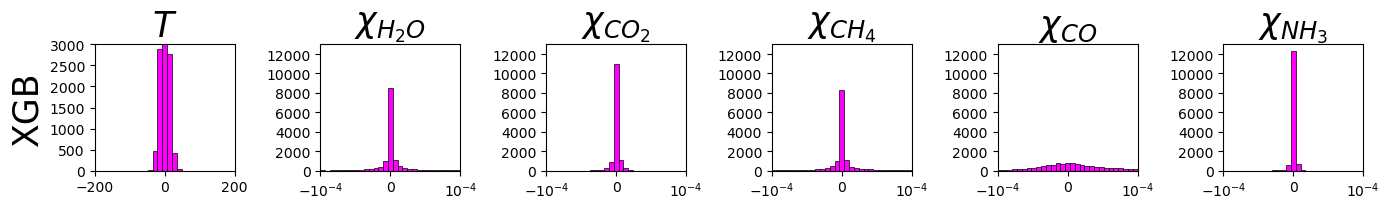

In [131]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000


for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_xg[:,i]-y_test_back_xg[:,i],bins=np.linspace(-tlim,tlim,30),color='magenta',lw=0.5,edgecolor = "black")
        plt.ylabel('XGB',fontsize=25)
    else:
        plt.hist(y_pred_back_xg[:,i]-y_test_back_xg[:,i],bins=np.linspace(-clim,clim,30),color='magenta',lw=0.5,edgecolor = "black")

    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
    plt.title(keys[i], fontsize = 25)
fig.tight_layout()
plt.savefig(plots_path+'error_xgb_'+designation+'.png',bbox_inches='tight')

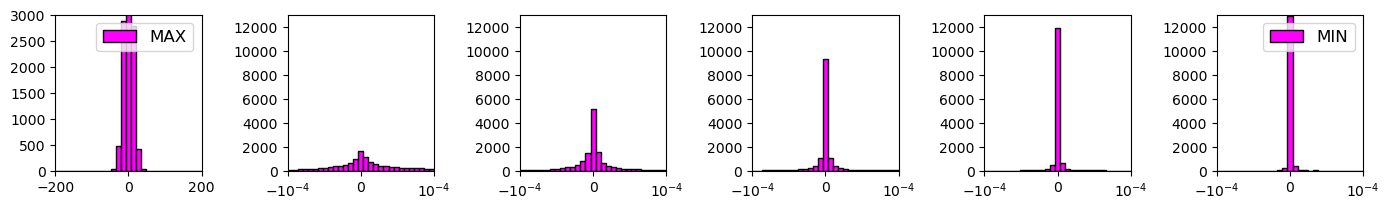

In [132]:
fig,axs = plt.subplots(1,6,figsize=(14,2.2))

tlim = 200
clim = 1e-4
ytlim = 3000
yclim = 13000
ytinc = 500
ycinc = 2000

for i in range(len(keys)):
    plt.subplot(161+i)
    if i==0:
        plt.hist(y_pred_back_xg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_xg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-tlim,tlim,30),color='magenta',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    elif i==5:
        plt.hist(y_pred_back_xg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_xg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='magenta',edgecolor = "black",label = keys_max_min[i])
        plt.legend(fontsize=12)
    else:
        plt.hist(y_pred_back_xg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i]-y_test_back_xg[inds0,inds1].reshape(y_test.shape[0],y_test.shape[1])[:,i],bins=np.linspace(-clim,clim,30),color='magenta',edgecolor = "black")
    if i>0:
        plt.xlim([-clim,clim])
        plt.ylim([0,yclim])
        plt.xticks(fontsize=10,ticks=[-1e-4,0,1e-4],labels=['$-10^{-4}$','0','$10^{-4}$'])
        plt.yticks(ticks = [i for i in range(0,yclim+1,ycinc)],fontsize=10)
    else:
        plt.xlim([-tlim,tlim])
        plt.ylim([0,ytlim])
        plt.xticks(fontsize=10)
        plt.yticks(ticks = [i for i in range(0,ytlim+1,ytinc)],fontsize=10)
fig.tight_layout()
plt.savefig(plots_path+'error_maxmin_xgb_'+designation+'.png',bbox_inches='tight')

## Comparing Regression Algorithms

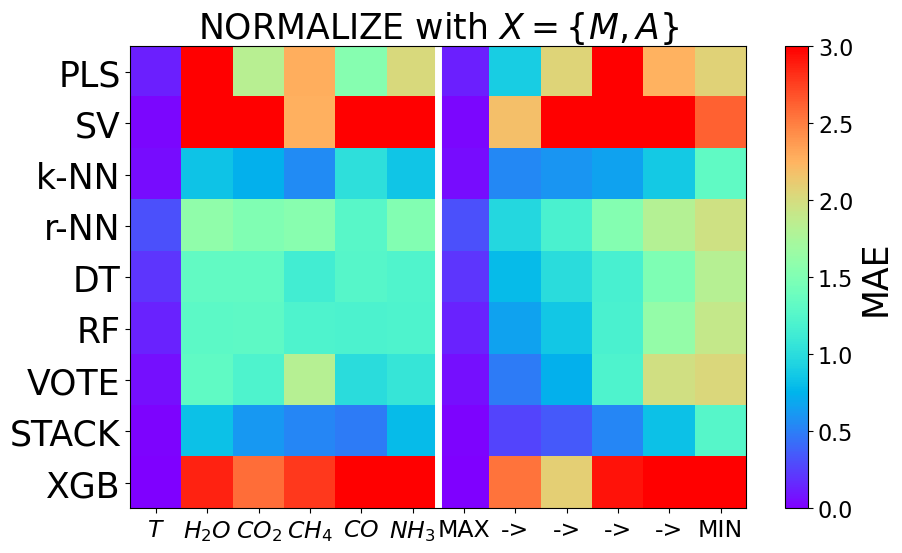

In [133]:
fig,ax = plt.subplots(1,1,figsize=(10,6))
im = plt.imshow(np.hstack([chart_array[:,:6],chart_array[:,6:12]]),cmap='rainbow',vmin=0,vmax=3)
plt.xticks(ticks = [i for i in range(chart_array.shape[1])],labels =['$T$','$H_2O$','$CO_2$','$CH_4$','$CO$','$NH_3$','MAX','->','->','->','->','MIN'],fontsize=17)
plt.yticks(ticks = [i for i in range(chart_array.shape[0])],labels=methods,fontsize=25)
plt.vlines(x=5.5, ymin=-0.5, ymax=8.5, colors='white', linestyles='solid',lw=5)
# plt.title('Comparing Regression Method Errors',fontsize=25)
plt.title('NORMALIZE with $X = \{ M, A \}$',fontsize=25)
cbar = plt.colorbar(im)
cbar.set_label(label='MAE',size=25)
cbar.ax.tick_params(labelsize=16)
plt.savefig(plots_path+'exo_regression_mae_'+designation+'.png')

In [134]:
np.max(chart_array)

5.2638161004105735

In [135]:
np.mean(chart_array)

1.4591225215645525

In [136]:
np.save(plots_path+'mae_chart_'+designation+'.npy',chart_array)